# Matrices de covarianza wavelet — S01

Descomposición DWT (db4, algoritmo à trous) → 5 bandas EEG/6 canales → 30 series temporales → matriz de covarianza 30×30.

Para cada grupo: media y desviación estándar de las matrices de covarianza entre todos los trials del grupo.

Al final: matrices diferencia que aíslan el efecto del parpadeo y de la pronunciación.

In [45]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white')

## 1. Funciones auxiliares

Extraídas de `src/like_bolanos_rufiner/preprocess.py`. Implementan la descomposición wavelet modificada (algoritmo à trous) con db4 para obtener 5 bandas EEG estándar de igual longitud.

In [46]:
_WAVELET_OBJ = pywt.Wavelet("db4")
_WAVELET_LO = np.asarray(_WAVELET_OBJ.dec_lo)
_WAVELET_HI = np.asarray(_WAVELET_OBJ.dec_hi)

def dilate_filter(filt, factor):
    if factor == 1:
        return filt
    dilated = np.zeros(len(filt) * factor)
    dilated[::factor] = filt
    return dilated

def conv_same_len(signal, filt):
    full_conv = np.convolve(signal, filt, mode='full')
    shift = (len(filt) - 1) // 2
    return full_conv[shift : shift + len(signal)]

def mdwt_5bands(vector):
    """
    Descompone una señal en 5 bandas EEG estándar usando wavelet db4.
    Output: (5, N/2) con bandas: delta, theta, alpha, beta, gamma.
    """
    vector = np.asarray(vector, dtype=np.float64)
    if len(vector) % 2 == 1:
        vector = np.append(vector, 0.0)

    gamma_band = conv_same_len(vector, _WAVELET_HI)[::2]   # 32-64 Hz
    L1 = conv_same_len(vector, _WAVELET_LO)[::2]            # 0-32 Hz

    beta_band = conv_same_len(L1, _WAVELET_HI)              # 16-32 Hz
    L2 = conv_same_len(L1, _WAVELET_LO)                     # 0-16 Hz

    lo_x2 = dilate_filter(_WAVELET_LO, 2)
    hi_x2 = dilate_filter(_WAVELET_HI, 2)
    L3_low = conv_same_len(L2, lo_x2)                       # 0-8 Hz
    alpha_band = conv_same_len(L2, hi_x2)                   # 8-16 Hz

    lo_x4 = dilate_filter(_WAVELET_LO, 4)
    hi_x4 = dilate_filter(_WAVELET_HI, 4)
    delta_band = conv_same_len(L3_low, lo_x4)               # 0-4 Hz
    theta_band = conv_same_len(L3_low, hi_x4)               # 4-8 Hz

    return np.vstack([delta_band, theta_band, alpha_band, beta_band, gamma_band])

## 2. Cargar datos del sujeto S01

688 trials, 6 canales (F3, F4, C3, C4, P3, P4), 512 muestras @ 128 Hz.

In [47]:
data_path = Path('../data/preprocessed_reshaped/S01_EEG.npz')
loader = np.load(data_path)
x = loader['x']  # (688, 6, 512)
y = loader['y']  # (688, 3): [modalidad, estimulo, artefacto]

N_TRIALS, N_CH, N_SAMPLES = x.shape
print(f"Trials: {N_TRIALS}, Canales: {N_CH}, Muestras: {N_SAMPLES}")
print(f"  y[:,0] modalidad: 1=Imaginada, 2=Pronunciada")
print(f"  y[:,2] artefacto: 1=Limpio, 2=Parpadeo")

BANDAS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CANALES = ['F3', 'F4', 'C3', 'C4', 'P3', 'P4']
N_BANDS = len(BANDAS)
N_FEAT = N_CH * N_BANDS  # 30

Trials: 688, Canales: 6, Muestras: 512
  y[:,0] modalidad: 1=Imaginada, 2=Pronunciada
  y[:,2] artefacto: 1=Limpio, 2=Parpadeo


## 3. Calcular matrices de covarianza

Para cada trial:
- 6 canales × `mdwt_5bands` → 5 matrices `(5, 256)`
- Concatenar verticalmente → `(30, 256)` — 30 series temporales
- `np.cov(mat)` → matriz de covarianza `(30, 30)`

In [48]:
cov_mats = np.zeros((N_TRIALS, N_FEAT, N_FEAT))

for t in range(N_TRIALS):
    bands_all = [mdwt_5bands(x[t, ch, :]) for ch in range(N_CH)]
    cov_mats[t] = np.cov(np.vstack(bands_all))

print(f"cov_mats shape: {cov_mats.shape}")

cov_mats shape: (688, 30, 30)


## 4. Agrupar por condiciones y calcular estadísticos

In [49]:
groups = [
    ("Todos", slice(None)),
    ("Parpadeo", y[:, 2] == 2),
    ("No parpadeo", y[:, 2] == 1),
    ("Pronunciación", y[:, 0] == 2),
    ("Imaginada", y[:, 0] == 1),
    ("Parpadeo + Pron", (y[:, 2] == 2) & (y[:, 0] == 2)),
    ("Parpadeo + Imag", (y[:, 2] == 2) & (y[:, 0] == 1)),
    ("Limpio + Pron", (y[:, 2] == 1) & (y[:, 0] == 2)),
    ("Limpio + Imag", (y[:, 2] == 1) & (y[:, 0] == 1)),
]

results = []
for name, mask in groups:
    subset = cov_mats[mask]
    mean_mat = np.mean(subset, axis=0)
    std_mat = np.std(subset, axis=0)
    results.append((name, mean_mat, std_mat, subset.shape[0]))
    print(f"{name:22s}  n={subset.shape[0]:4d}")

Todos                   n= 688
Parpadeo                n= 386
No parpadeo             n= 302
Pronunciación           n= 110
Imaginada               n= 578
Parpadeo + Pron         n=  86
Parpadeo + Imag         n= 300
Limpio + Pron           n=  24
Limpio + Imag           n= 278


## 5. Función de formato para anotaciones

Cada celda muestra `media` en un renglón y `desviación` en el siguiente.
Ejes etiquetados por canal y banda (`Canal_Banda`).

In [50]:
def fmt_val(x):
    if abs(x) >= 100:
        return f"{x:.0f}"
    elif abs(x) >= 10:
        return f"{x:.1f}"
    elif abs(x) >= 1:
        return f"{x:.2f}"
    else:
        return f"{x:.3f}"

def build_annot(mean_mat, std_mat):
    """Crea matriz de strings 'mean\nstd' para anotar el heatmap."""
    n = mean_mat.shape[0]
    annot = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            annot[i, j] = f"{fmt_val(mean_mat[i,j])}\n{fmt_val(std_mat[i,j])}"
    return annot

def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

FEAT_LABELS = [f"{ch}_{b}" for ch in CANALES for b in BANDAS]

def plot_cov_matrix(mean_mat, std_mat, title, n_trials, figsize=(30, 27)):
    """Heatmap con log(covarianza), normalizado por grupo, anotaciones en valor original."""
    annot = build_annot(mean_mat, std_mat)
    log_mat = signed_log(mean_mat)
    vmin, vmax = log_mat.min(), log_mat.max()

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(log_mat, ax=ax, cmap='cividis',
                vmin=vmin, vmax=vmax,
                annot=annot, fmt='',
                annot_kws={'size': 6, 'fontfamily': 'monospace'},
                xticklabels=FEAT_LABELS, yticklabels=FEAT_LABELS,
                cbar_kws={'label': 'log(covarianza)', 'shrink': 0.6})

    ax.set_xticklabels(FEAT_LABELS, rotation=90, fontsize=6)
    ax.set_yticklabels(FEAT_LABELS, rotation=0, fontsize=6)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)

    for p in range(N_BANDS, N_FEAT, N_BANDS):
        ax.hlines(p, *ax.get_xlim(), color='white', linewidth=2.5, zorder=5)
        ax.vlines(p, *ax.get_ylim(), color='white', linewidth=2.5, zorder=5)

    ax.set_title(f"{title}  (n={n_trials})", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## 6. Mapas de covarianza media por grupo

Cada figura normalizada según sus propios valores mínimo y máximo.
Cada casilla muestra `media` (1<sup>er</sup> renglón) y `desviación estándar` (2<sup>do</sup> renglón).

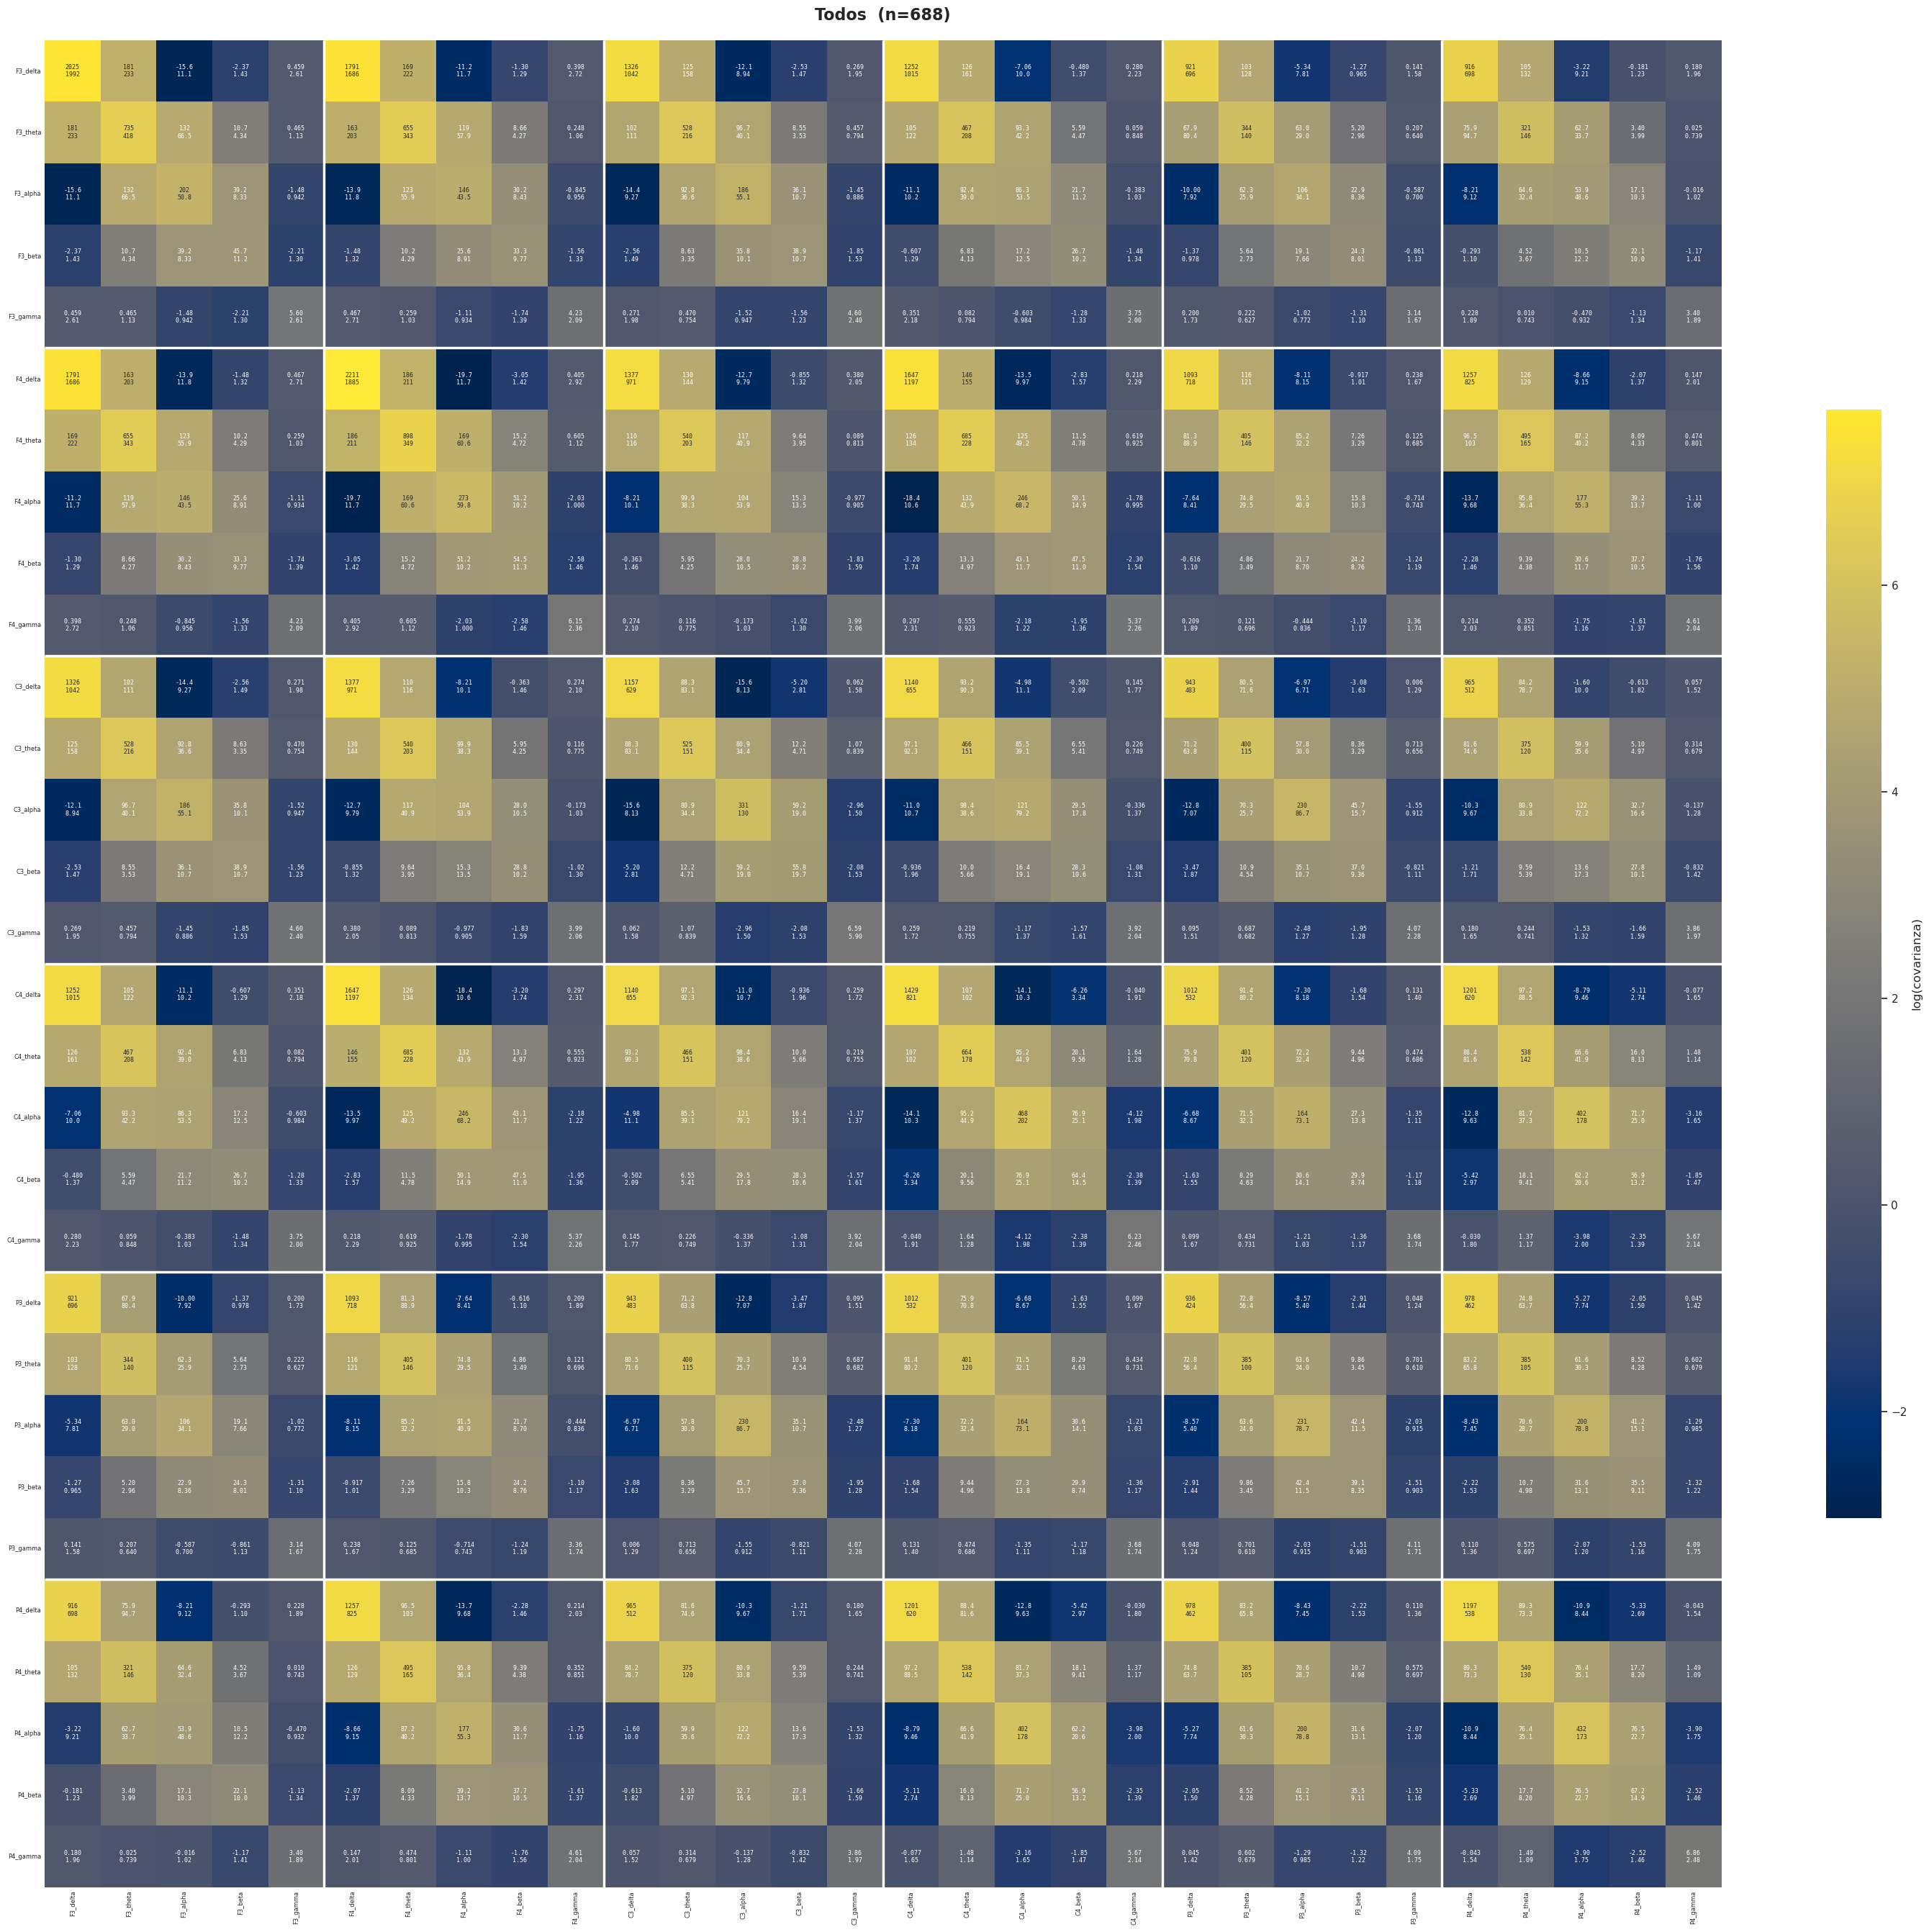

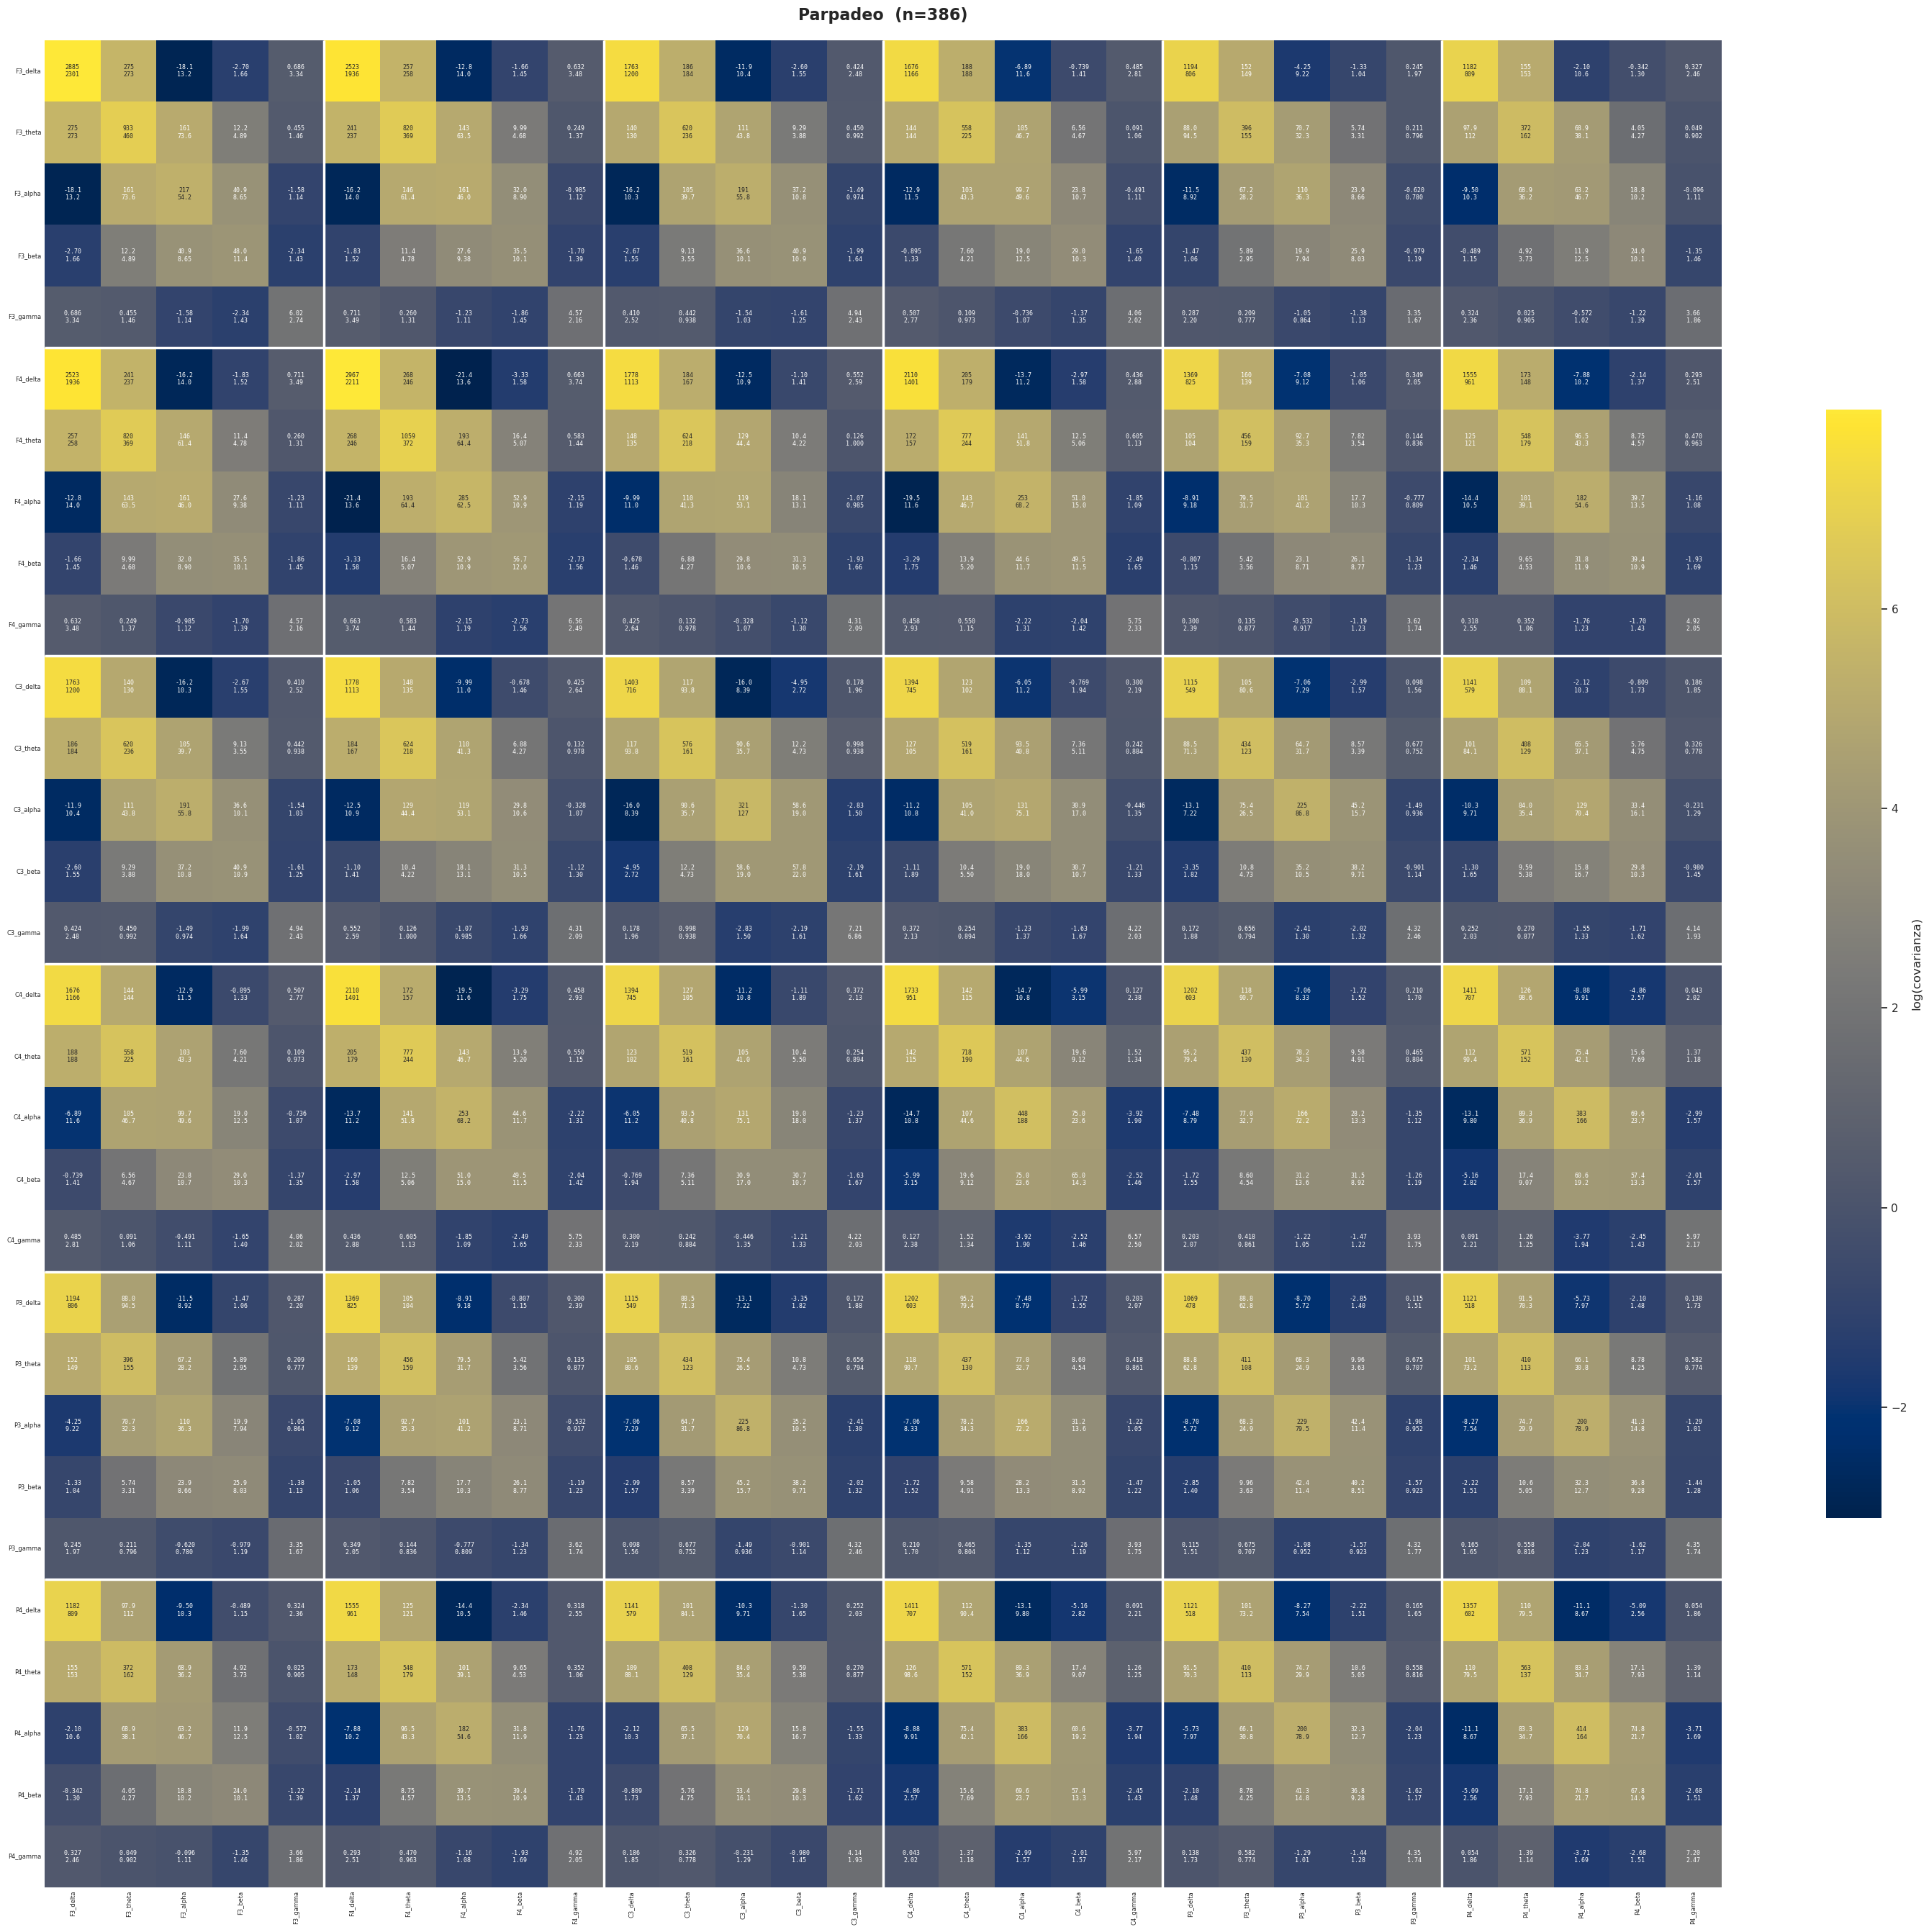

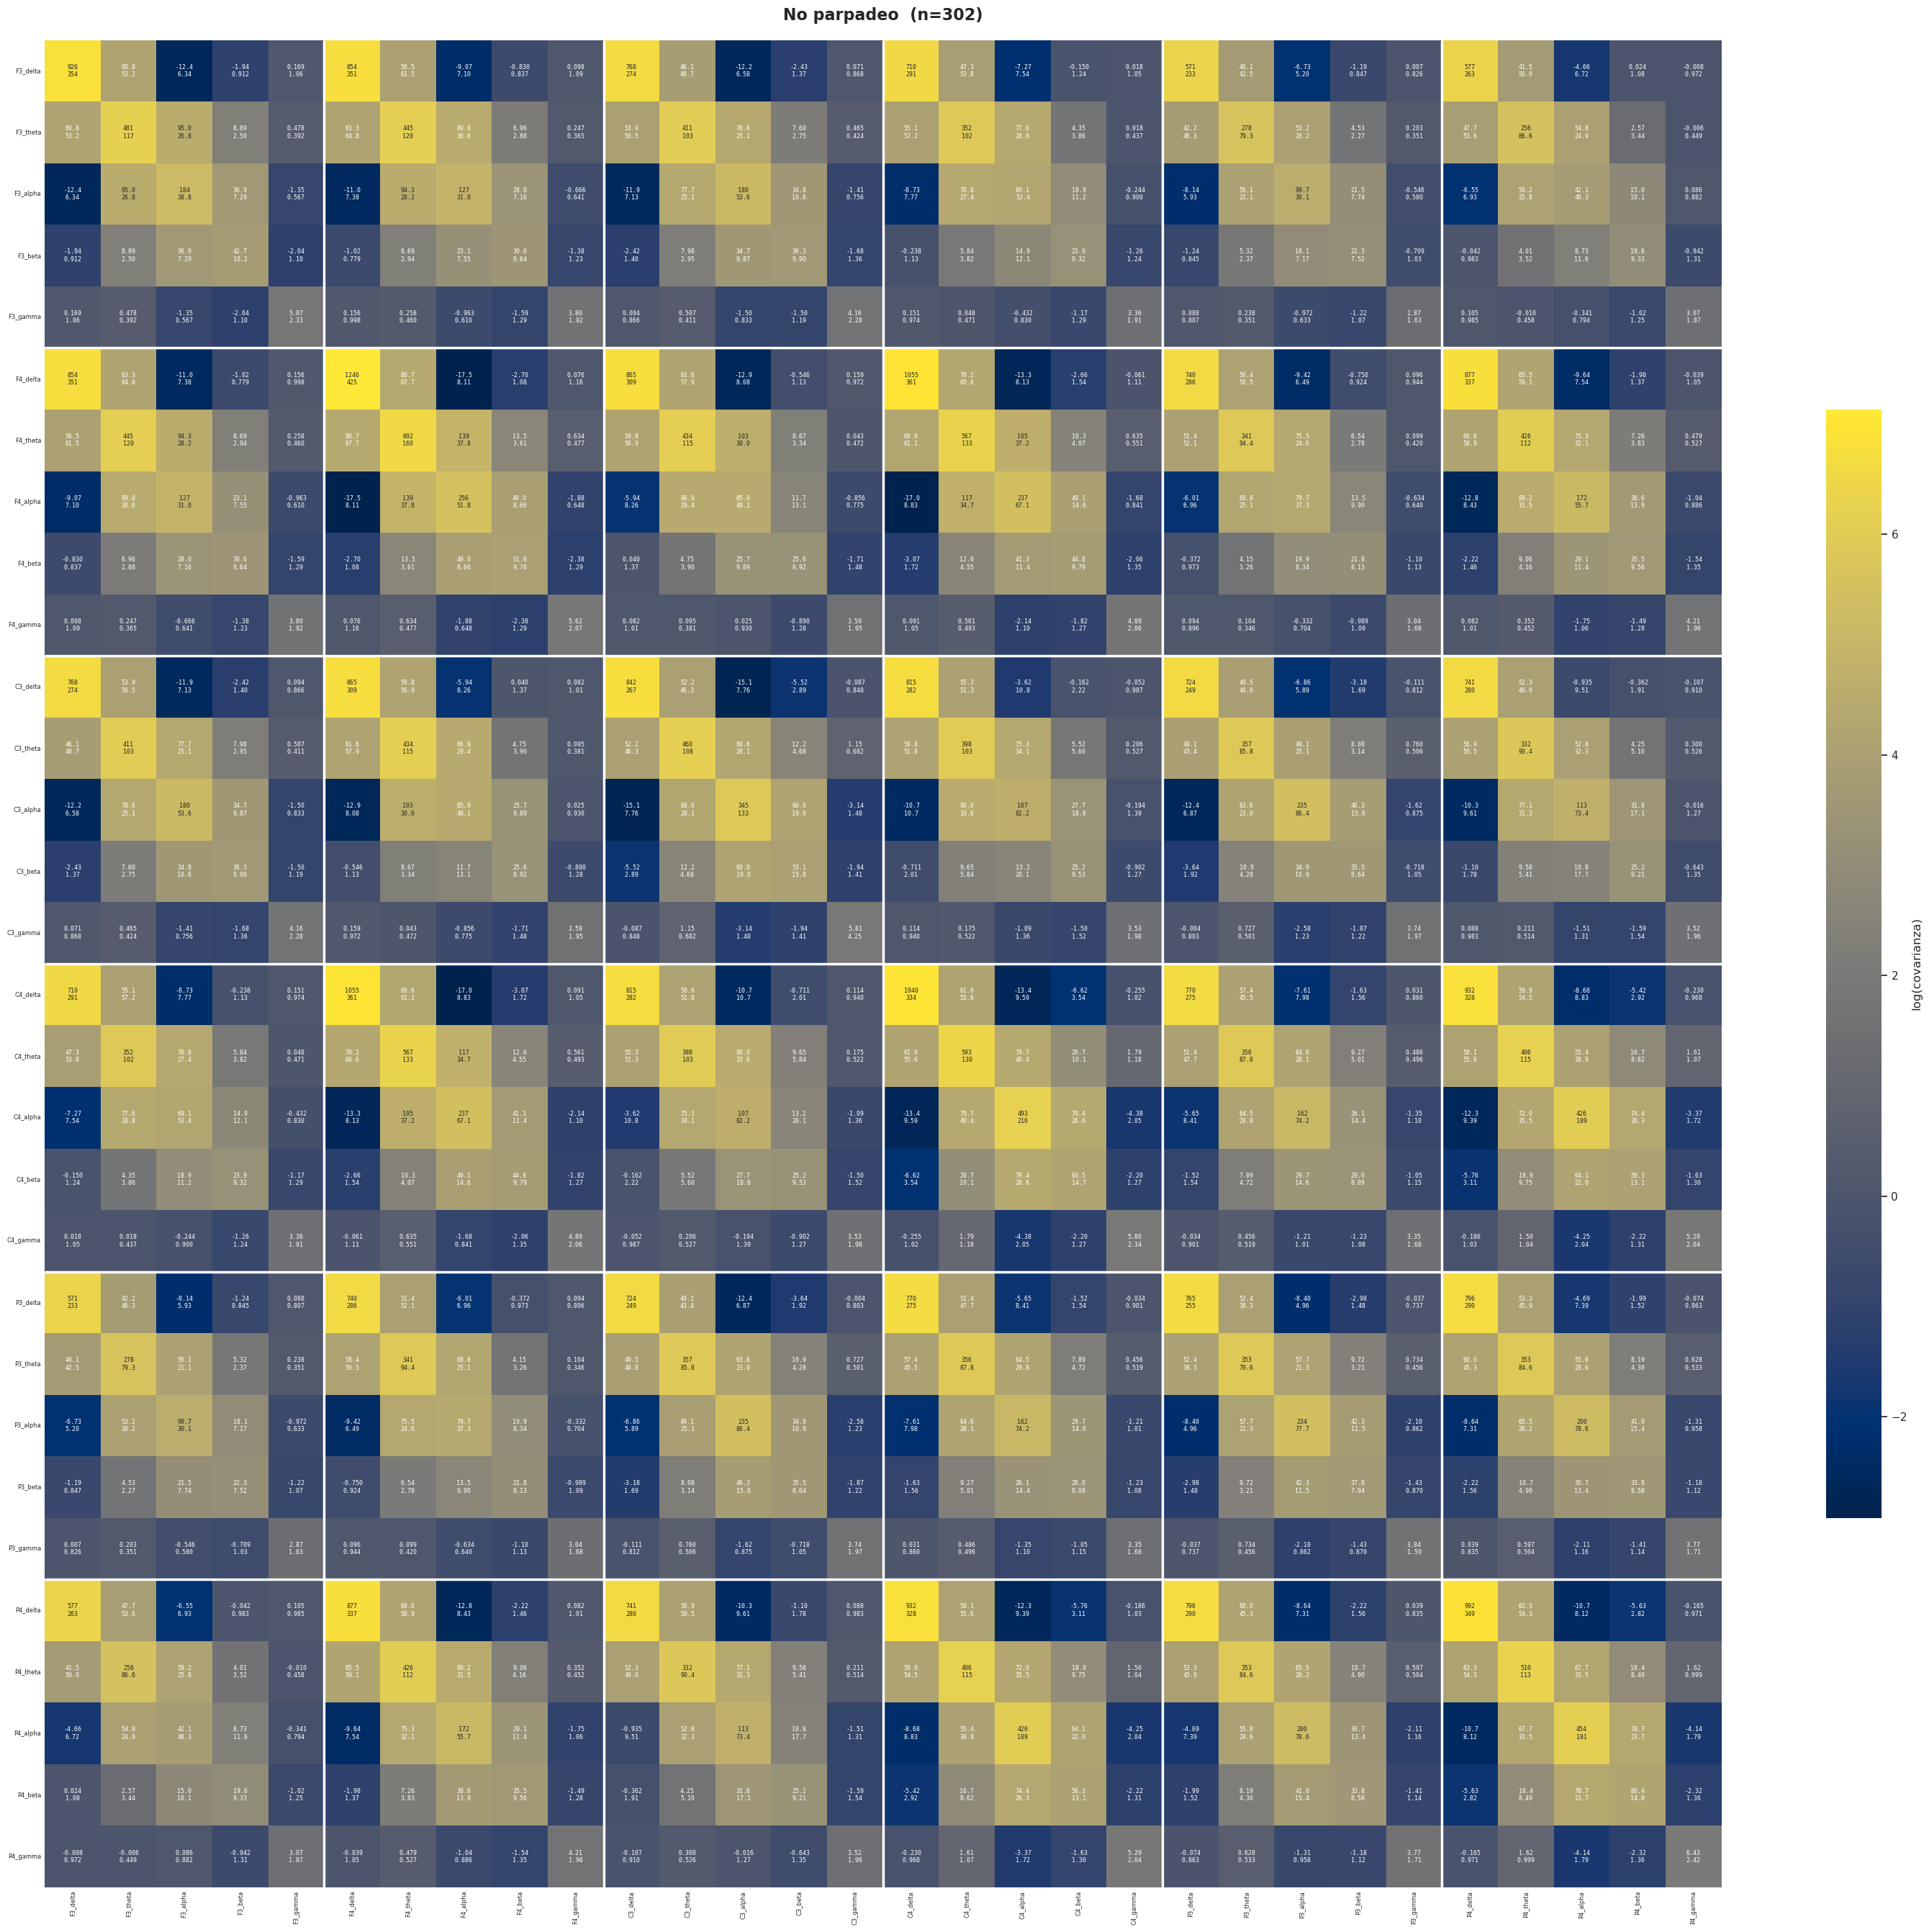

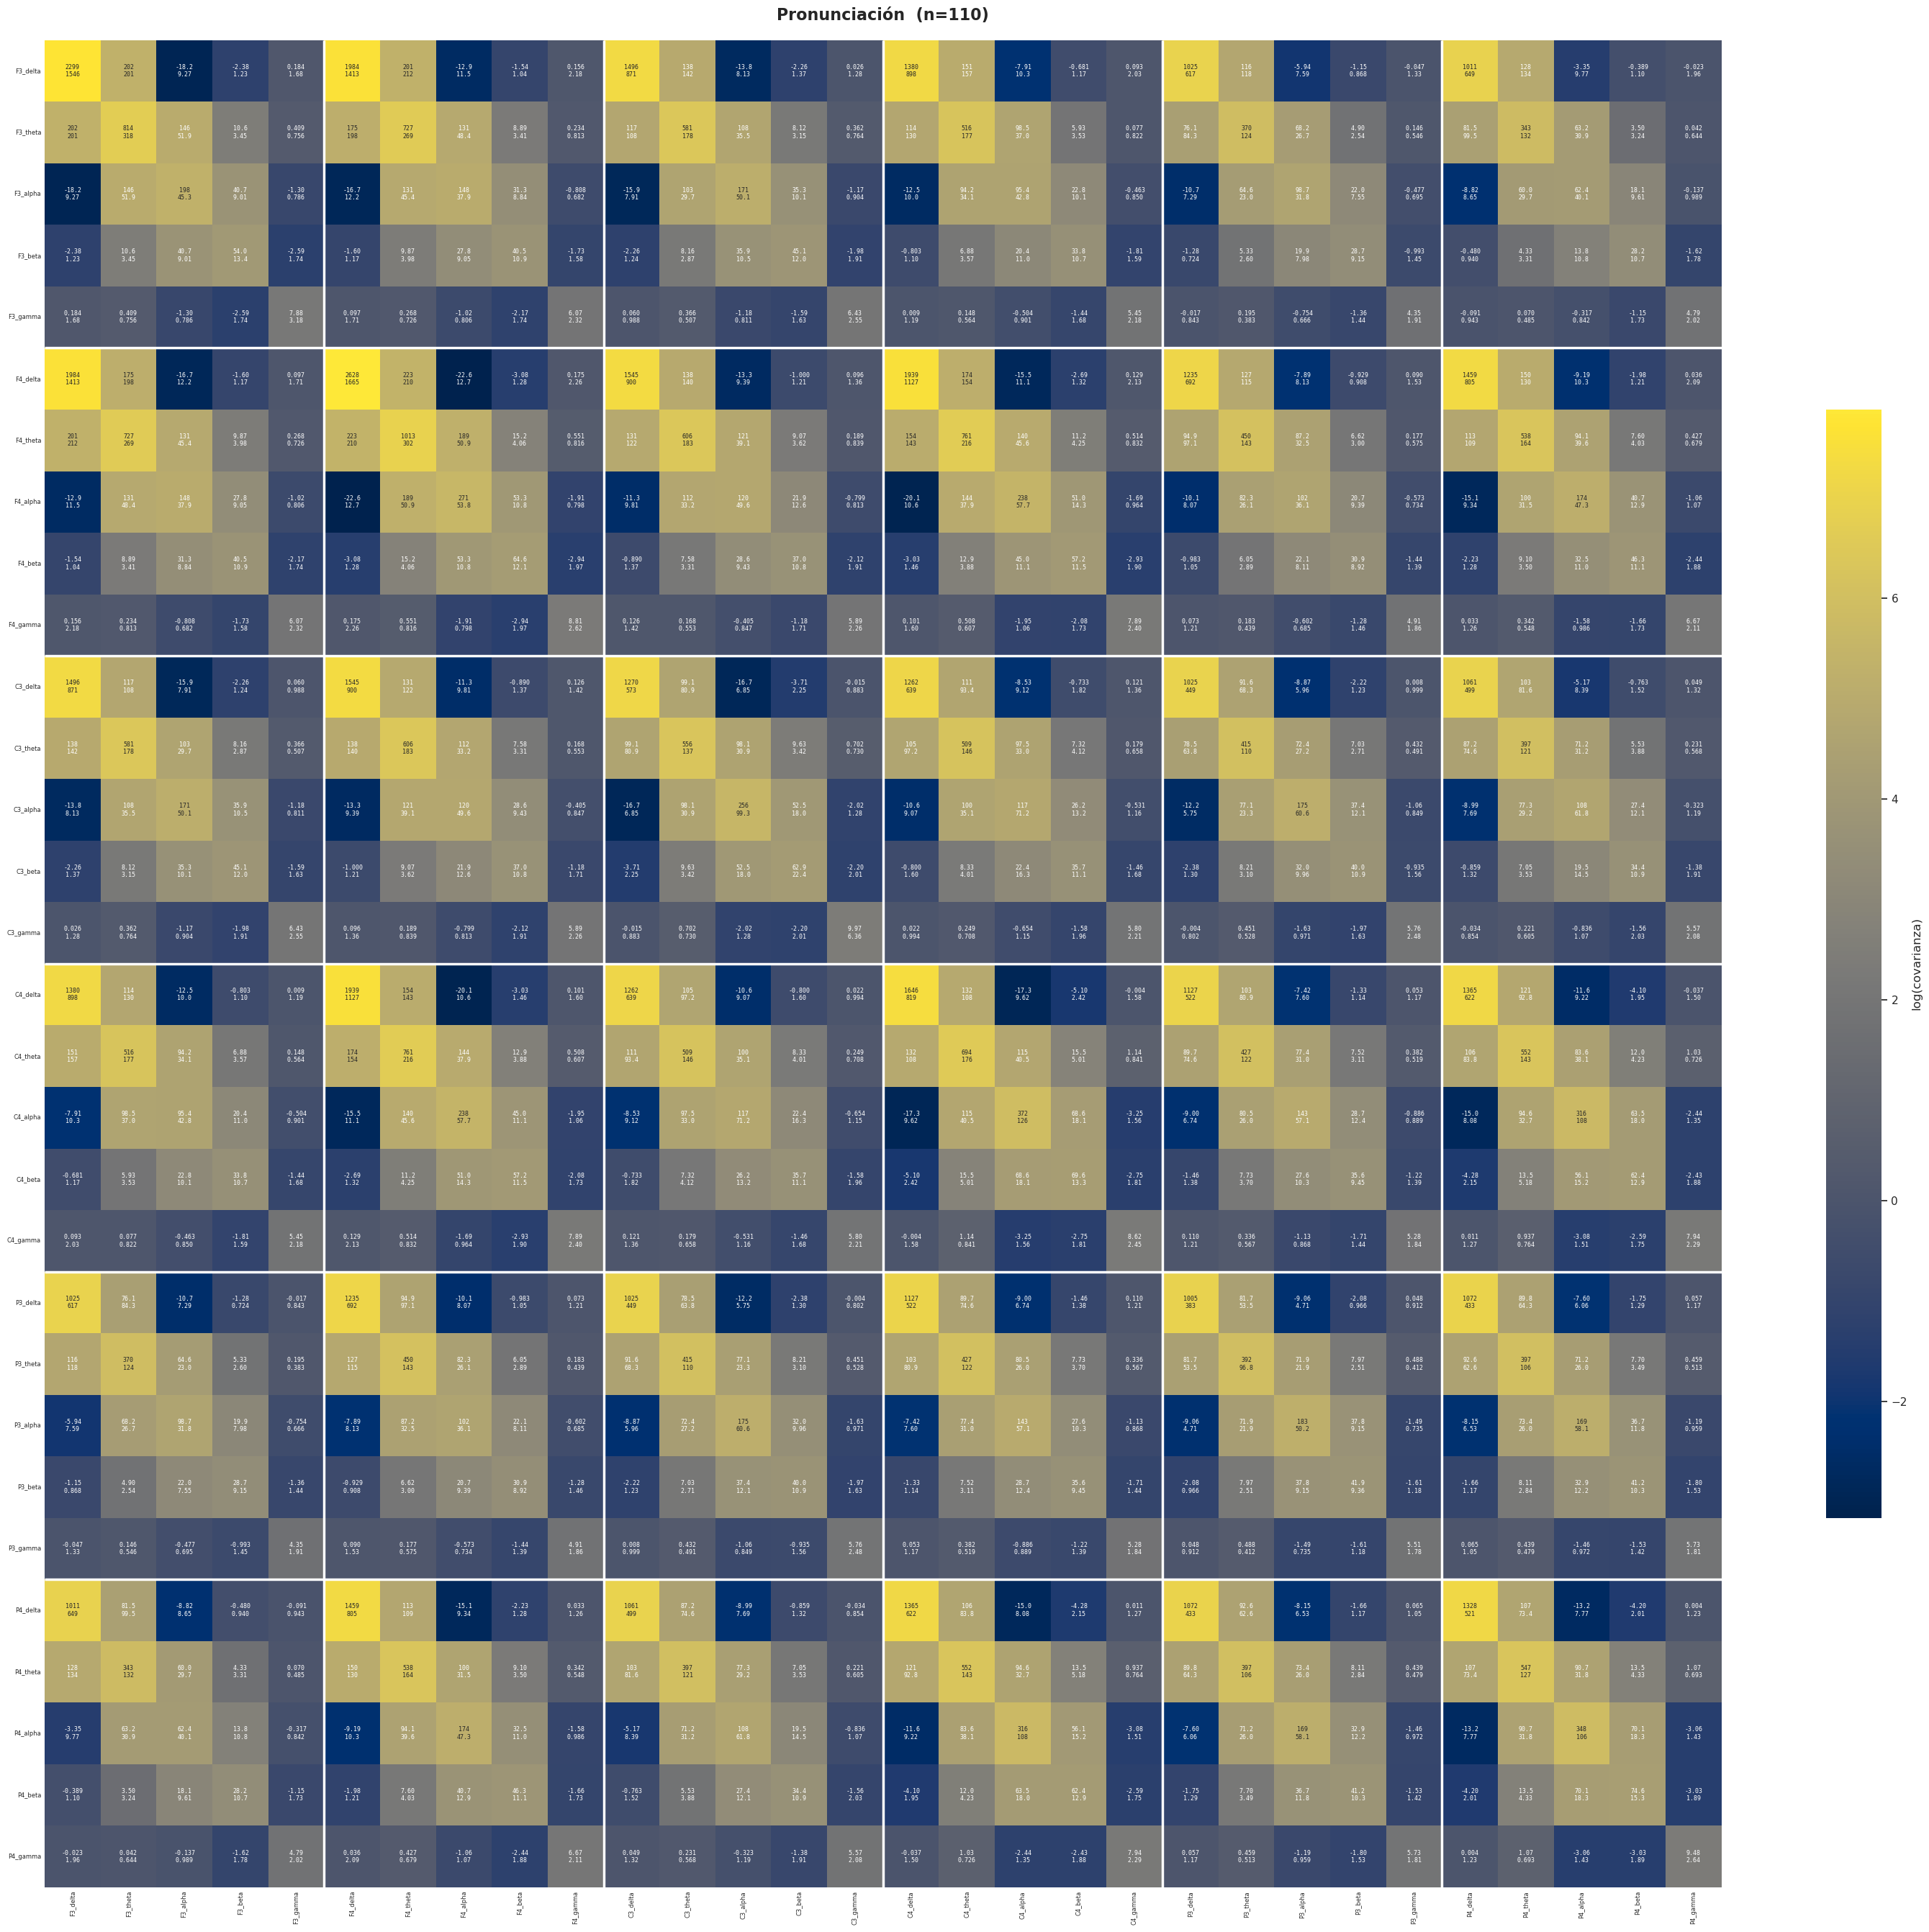

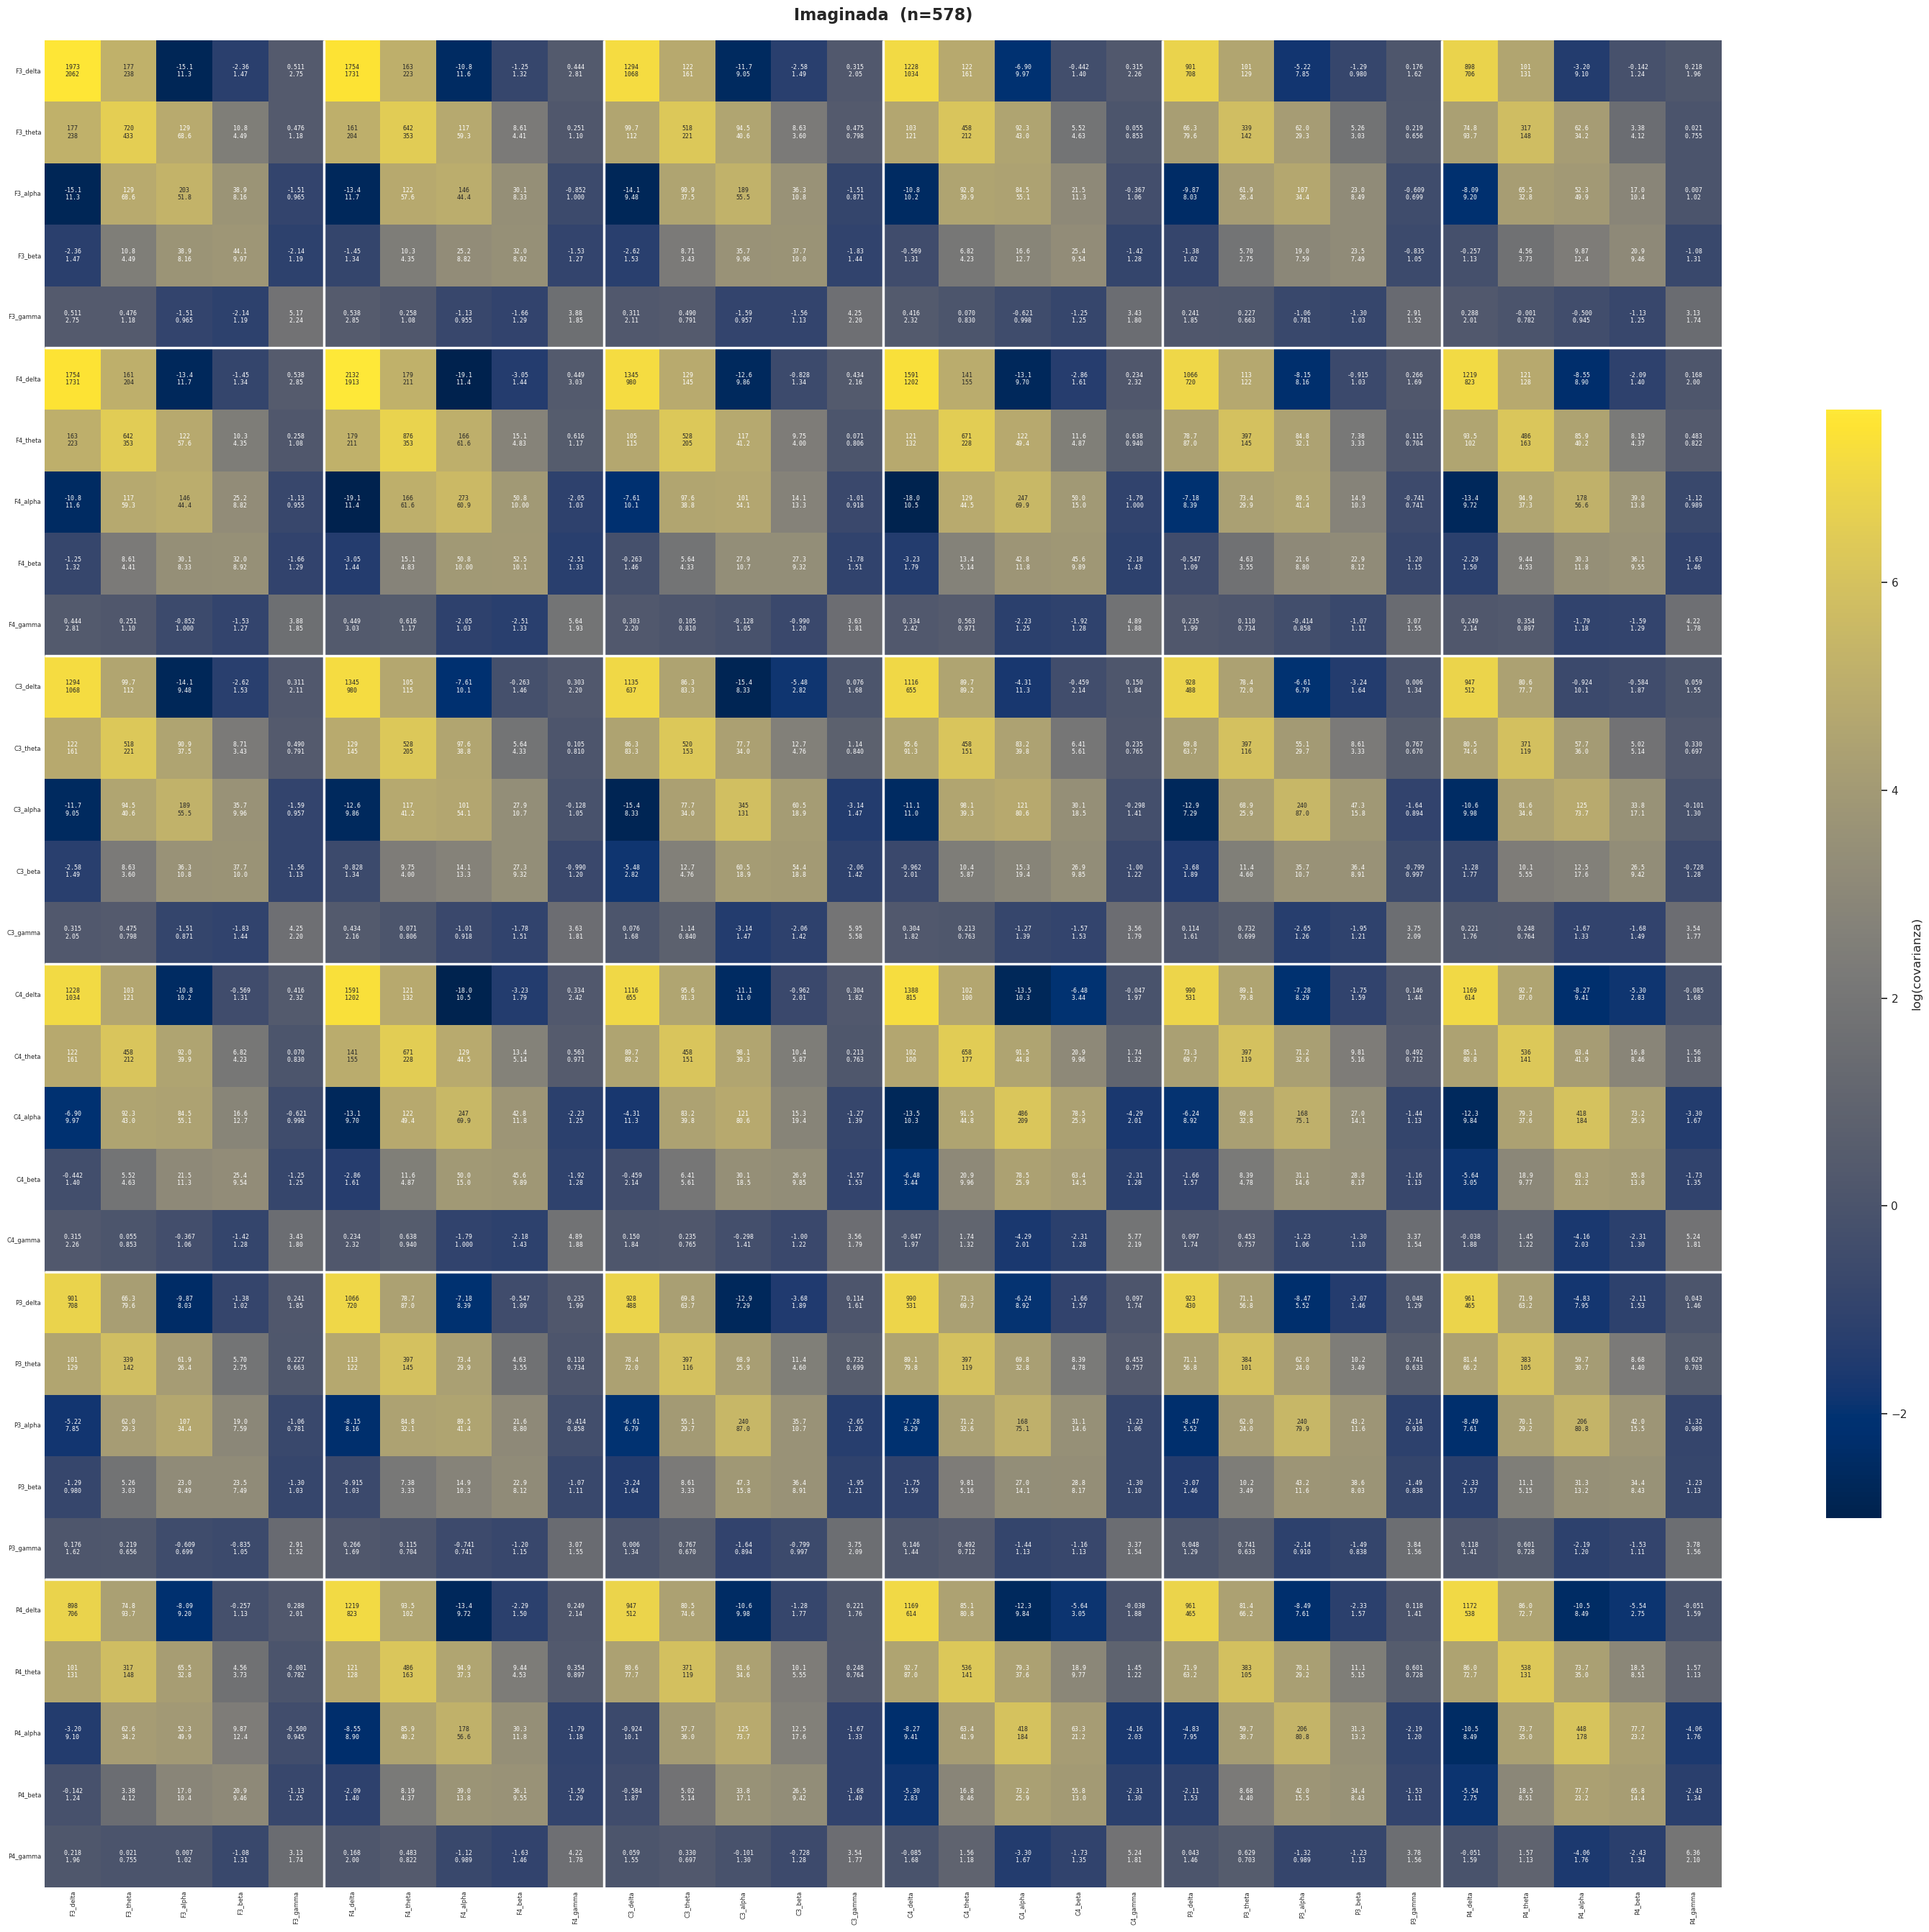

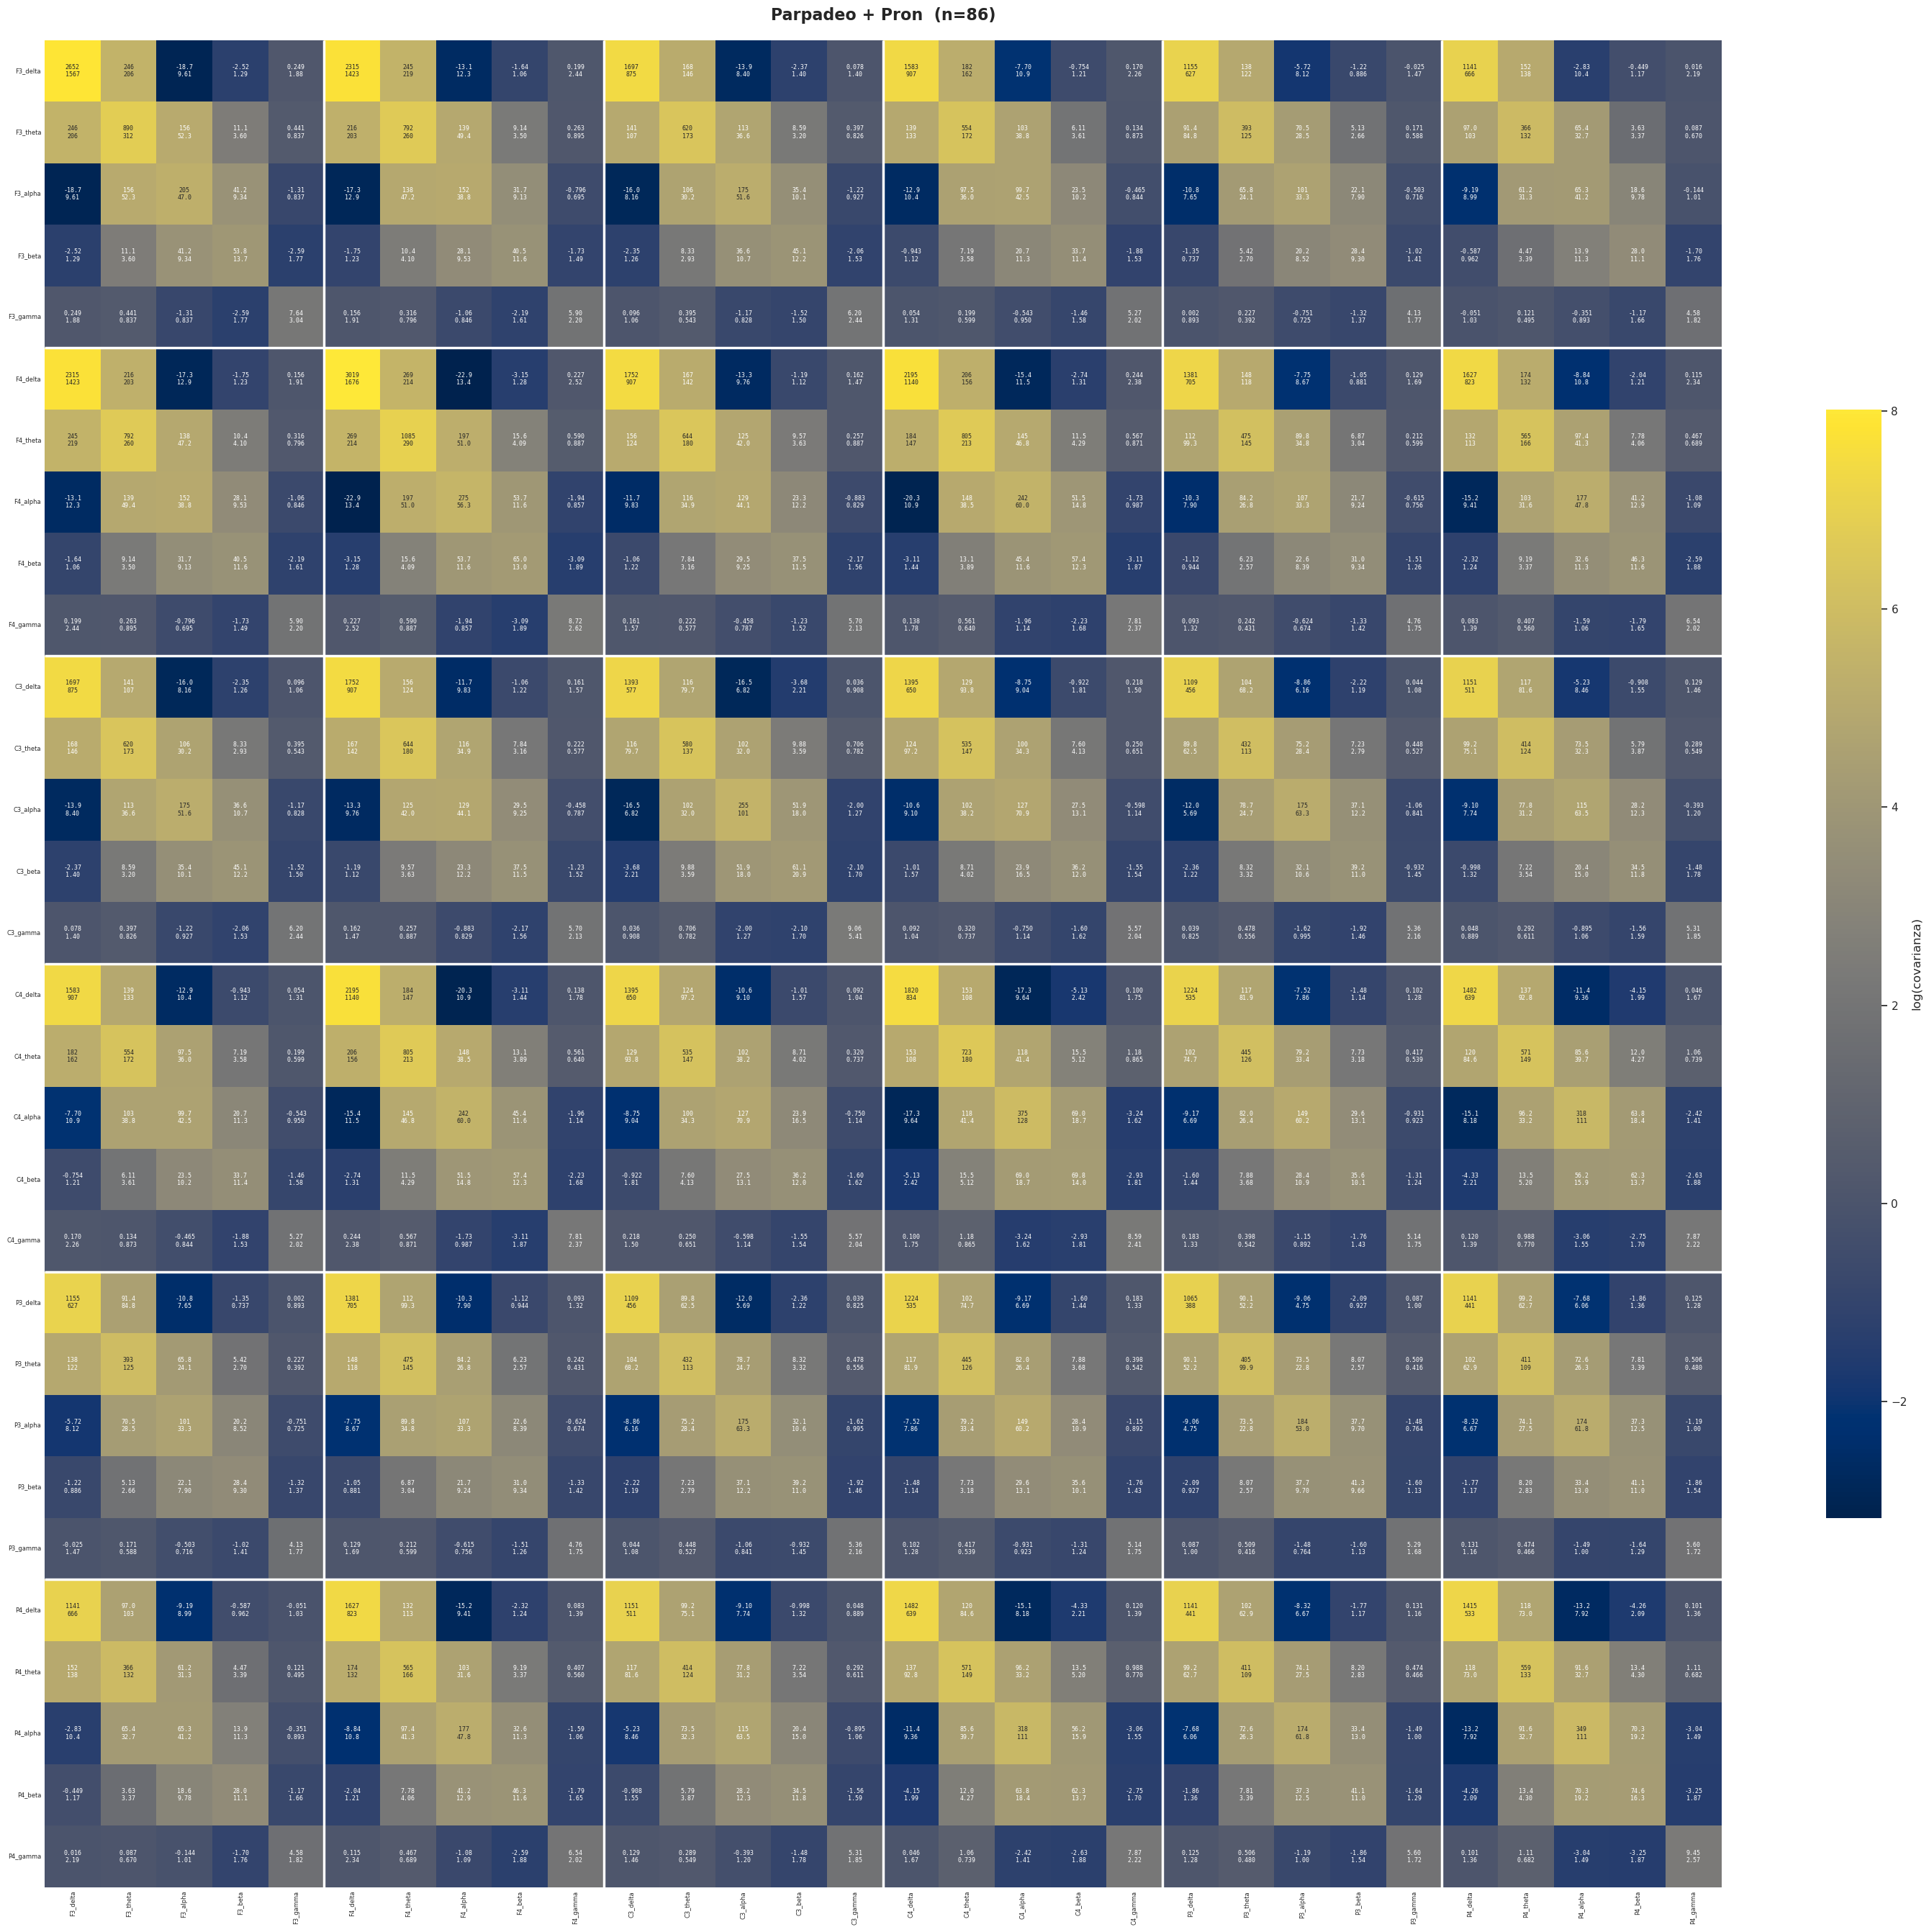

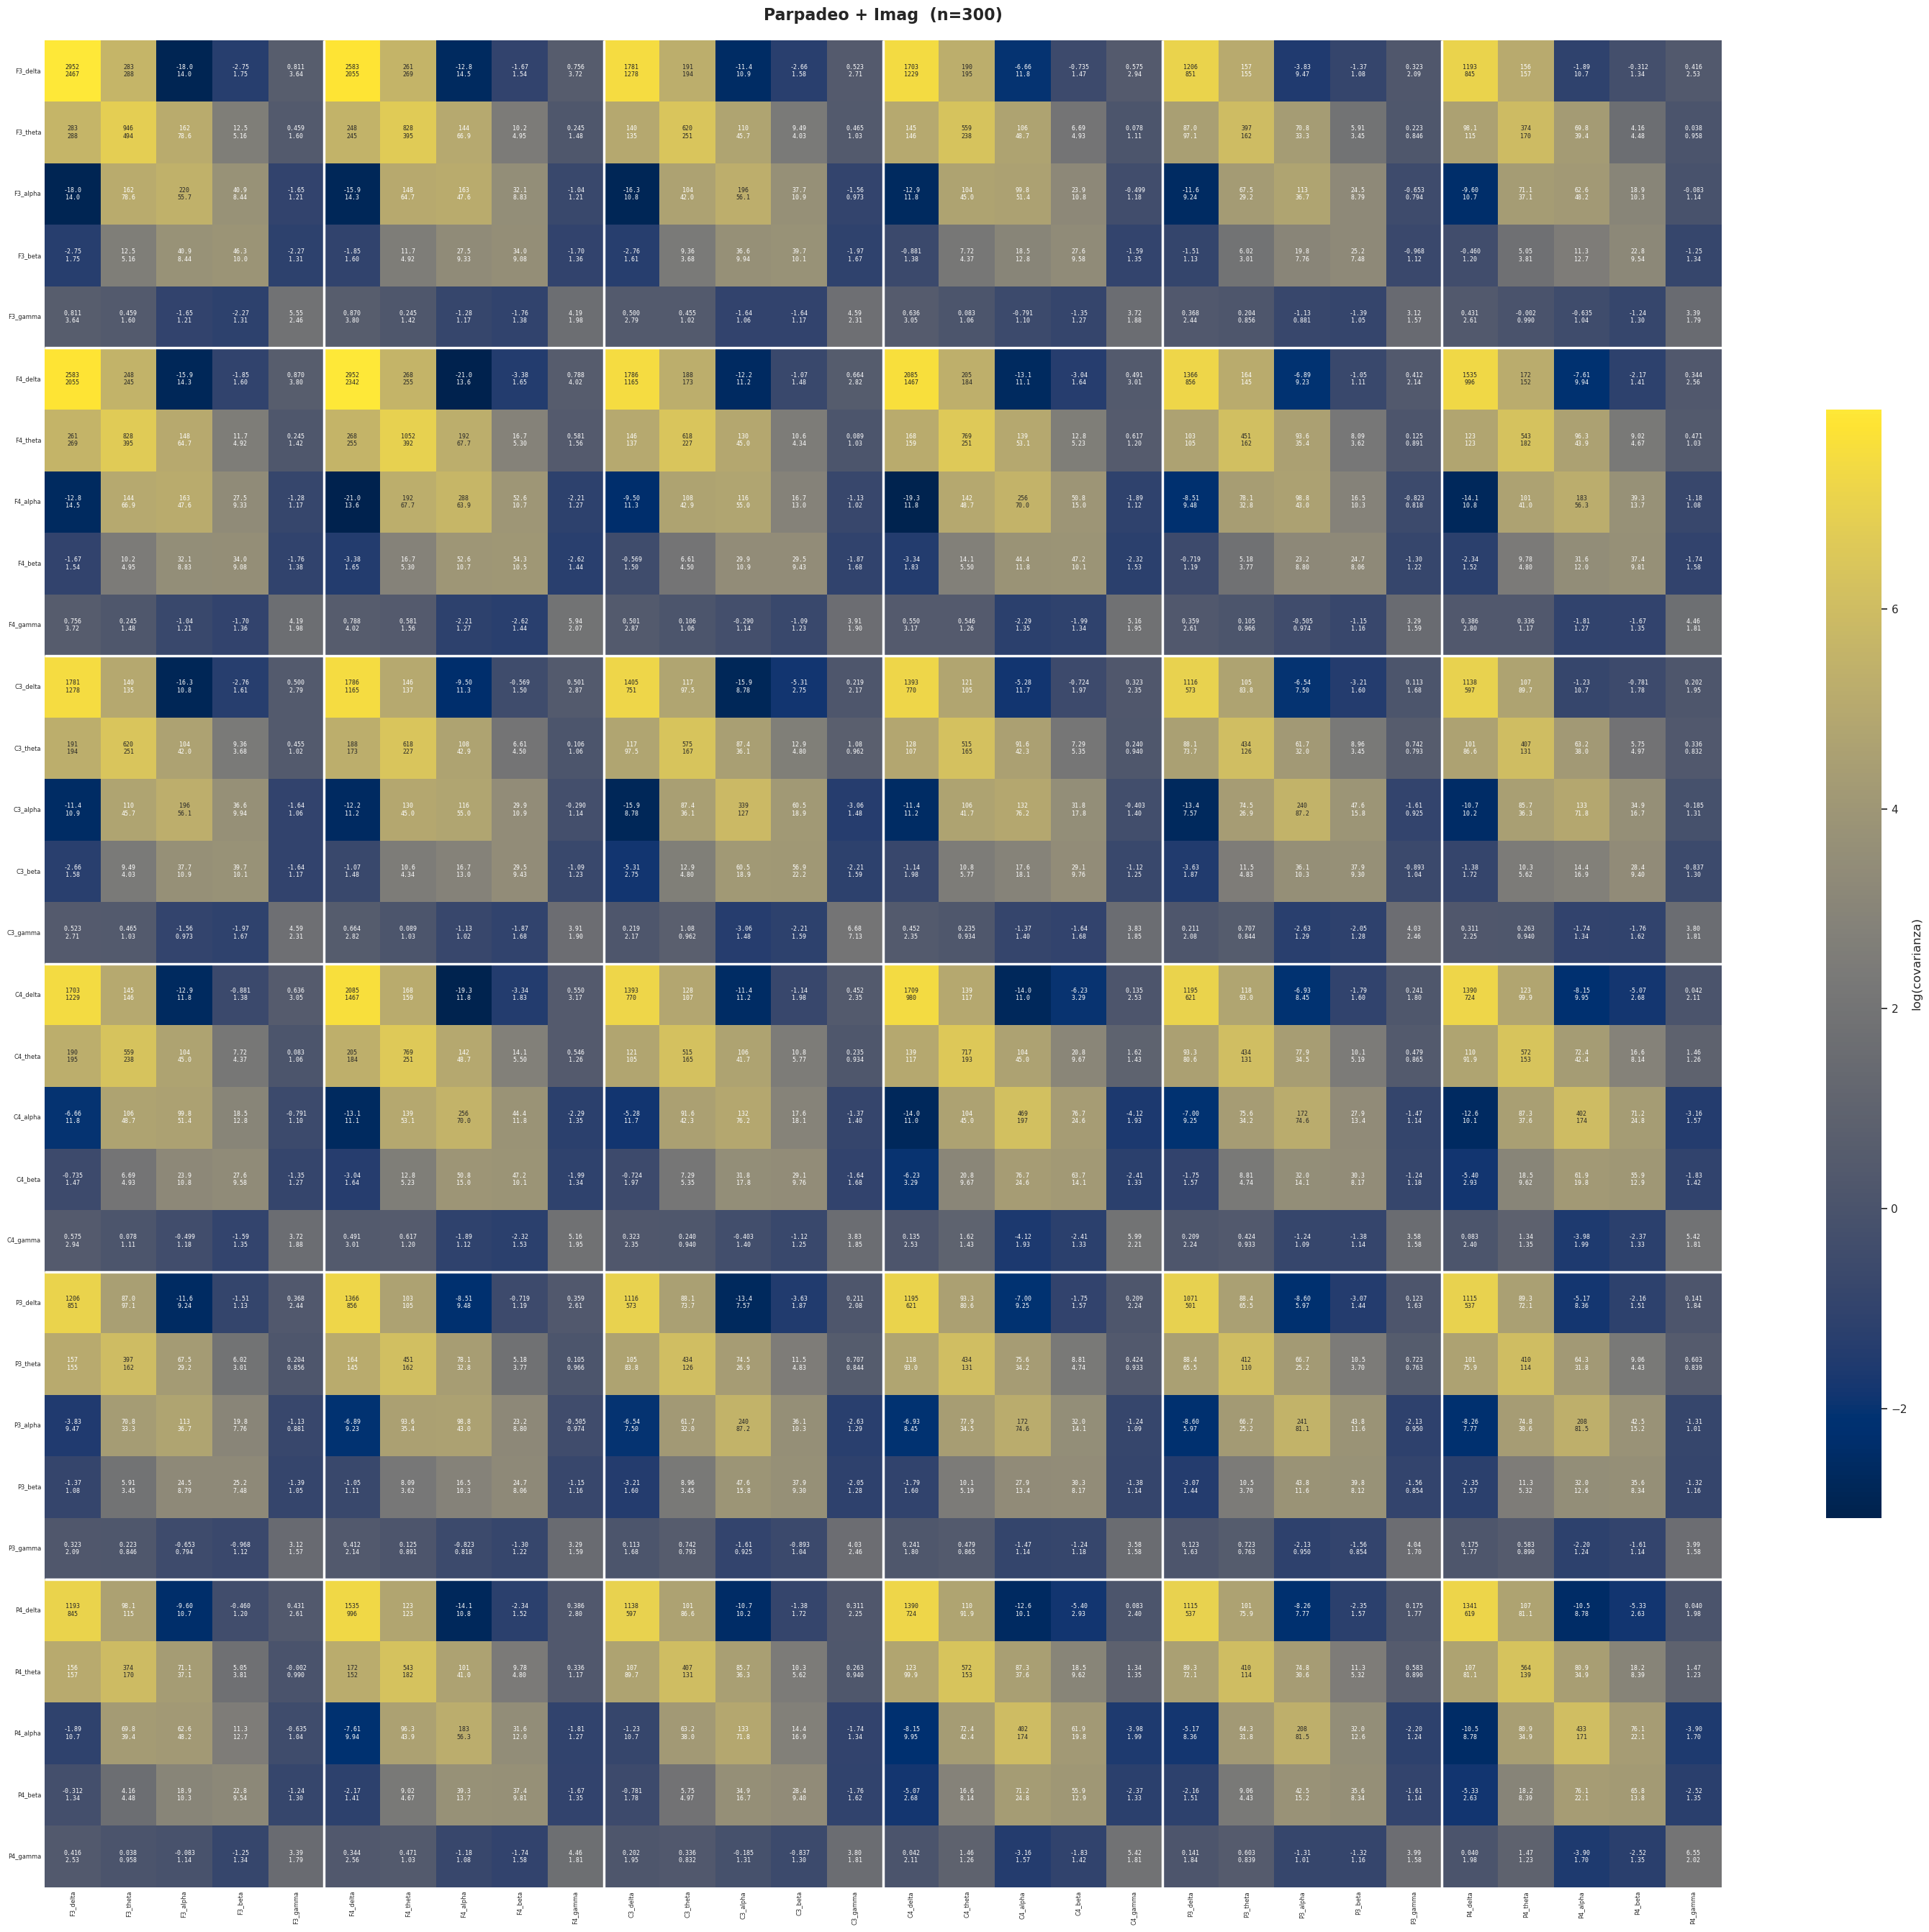

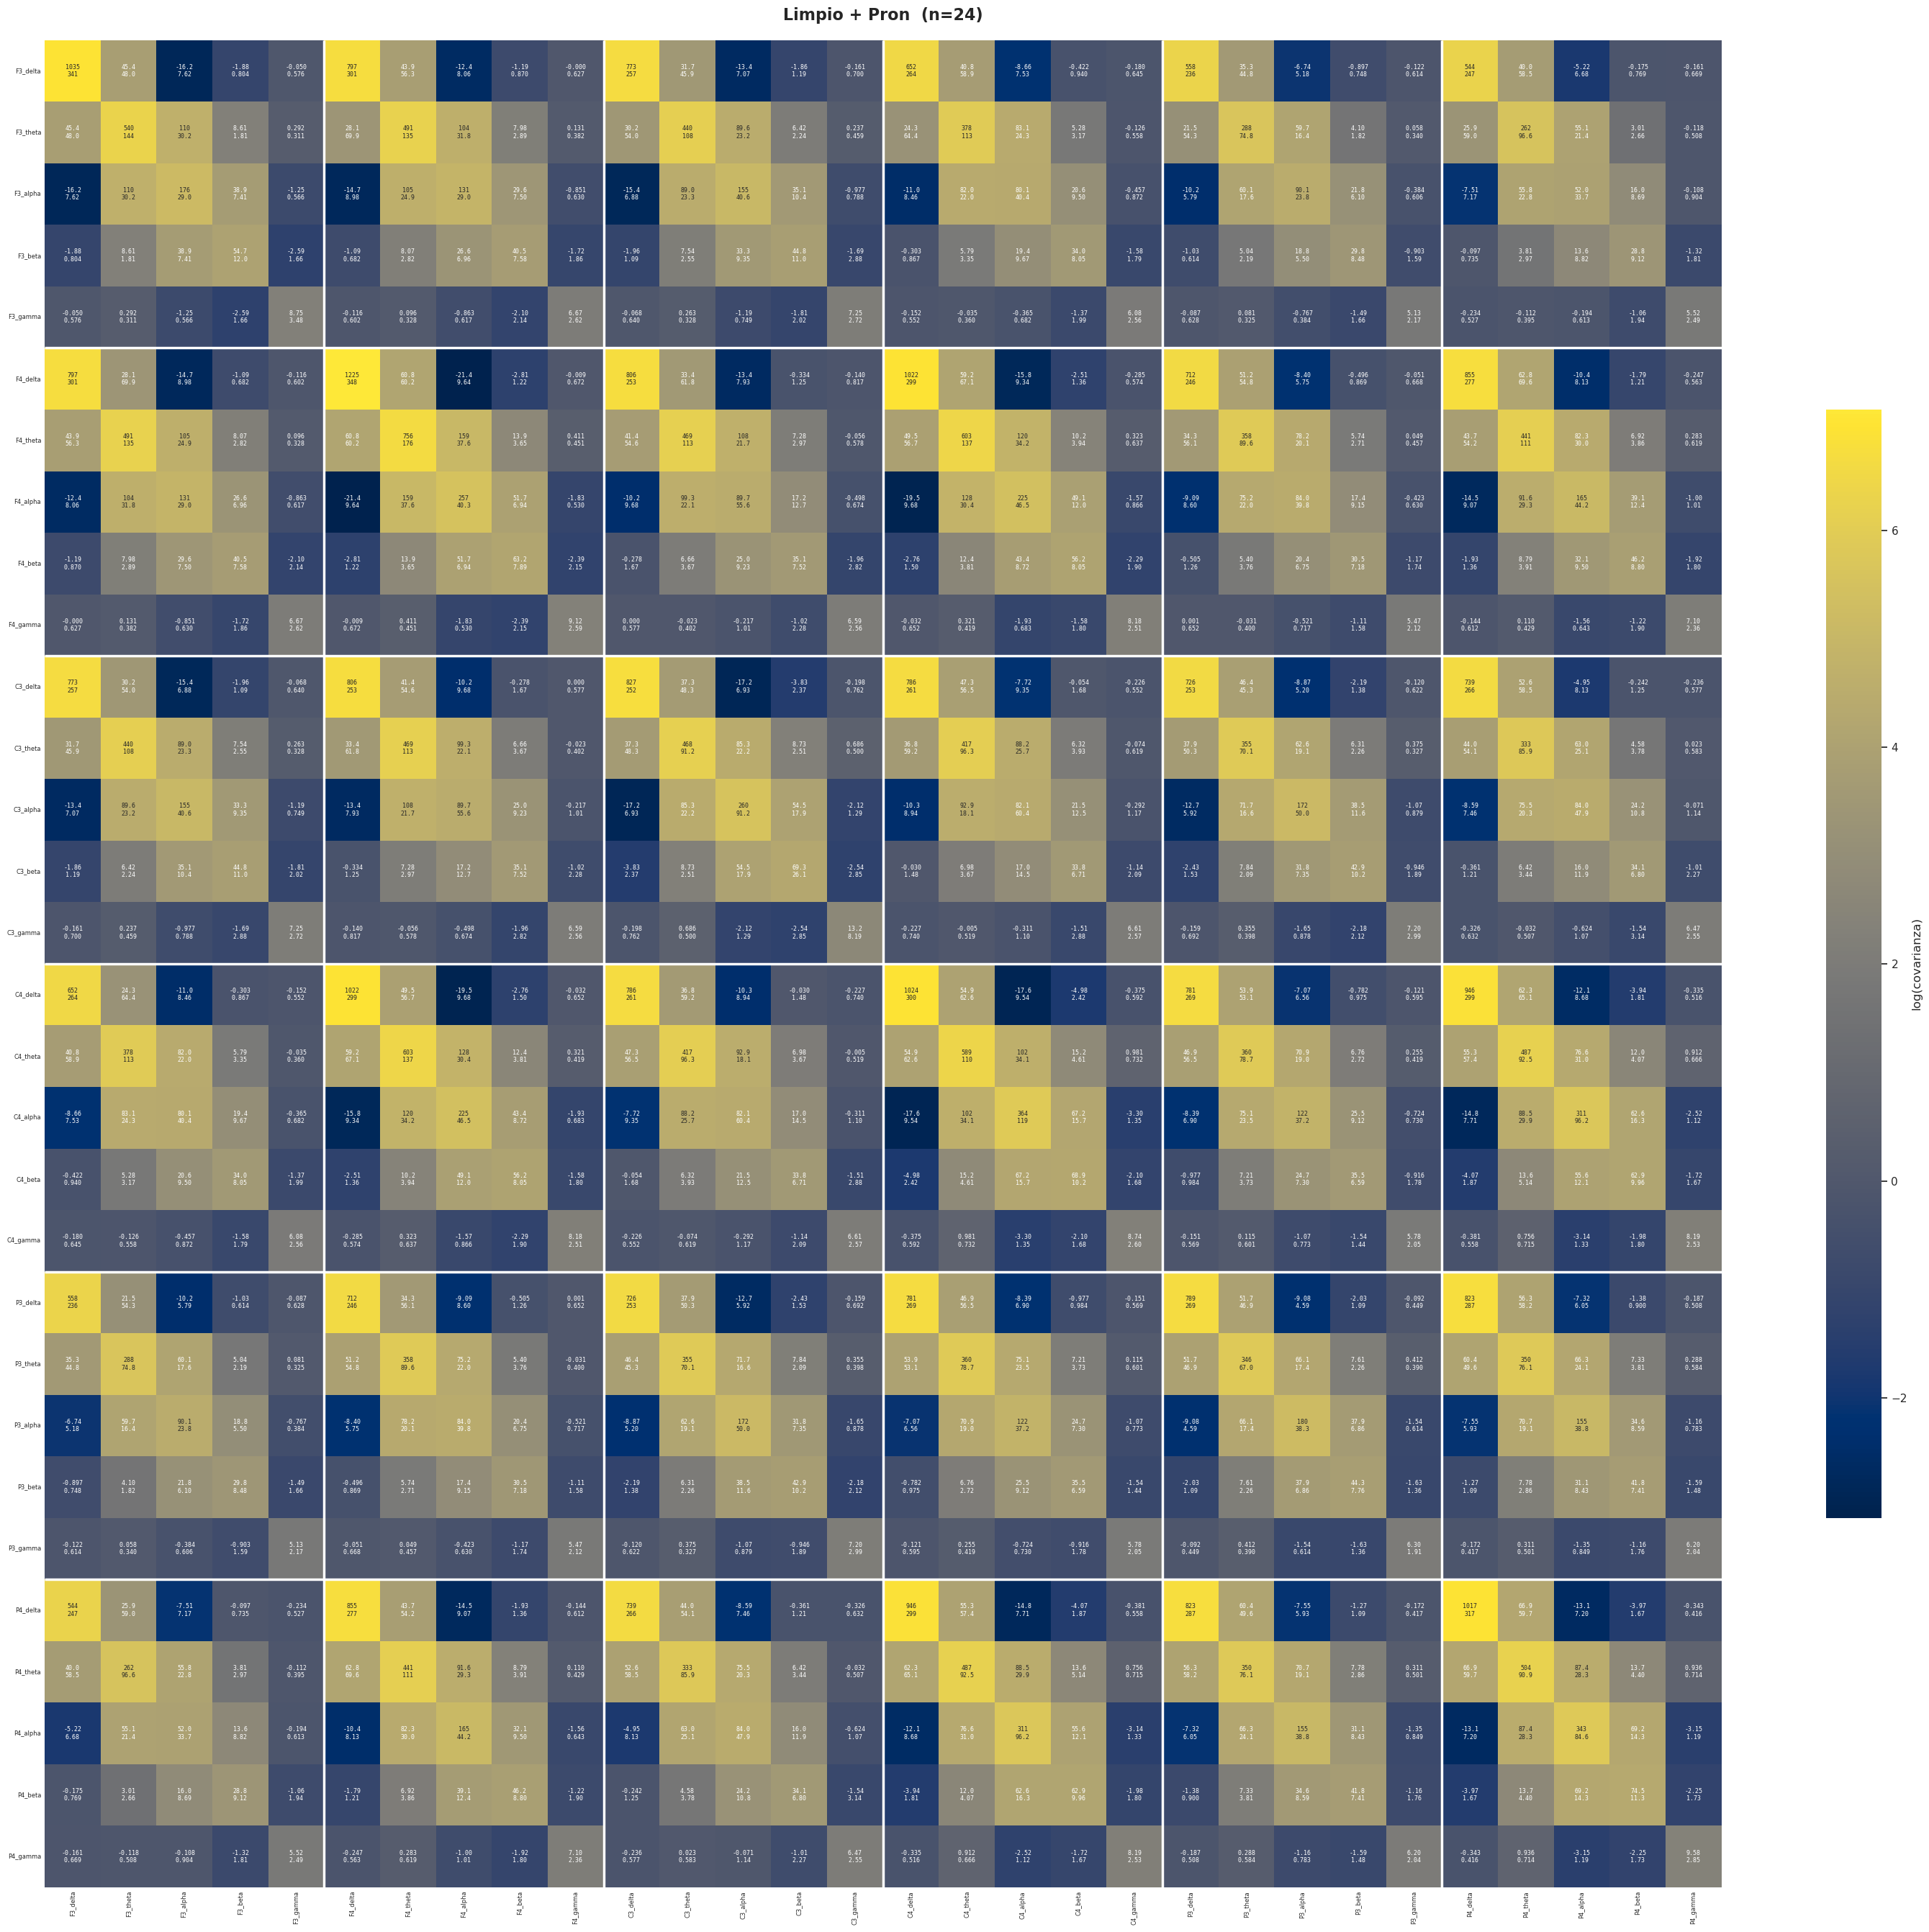

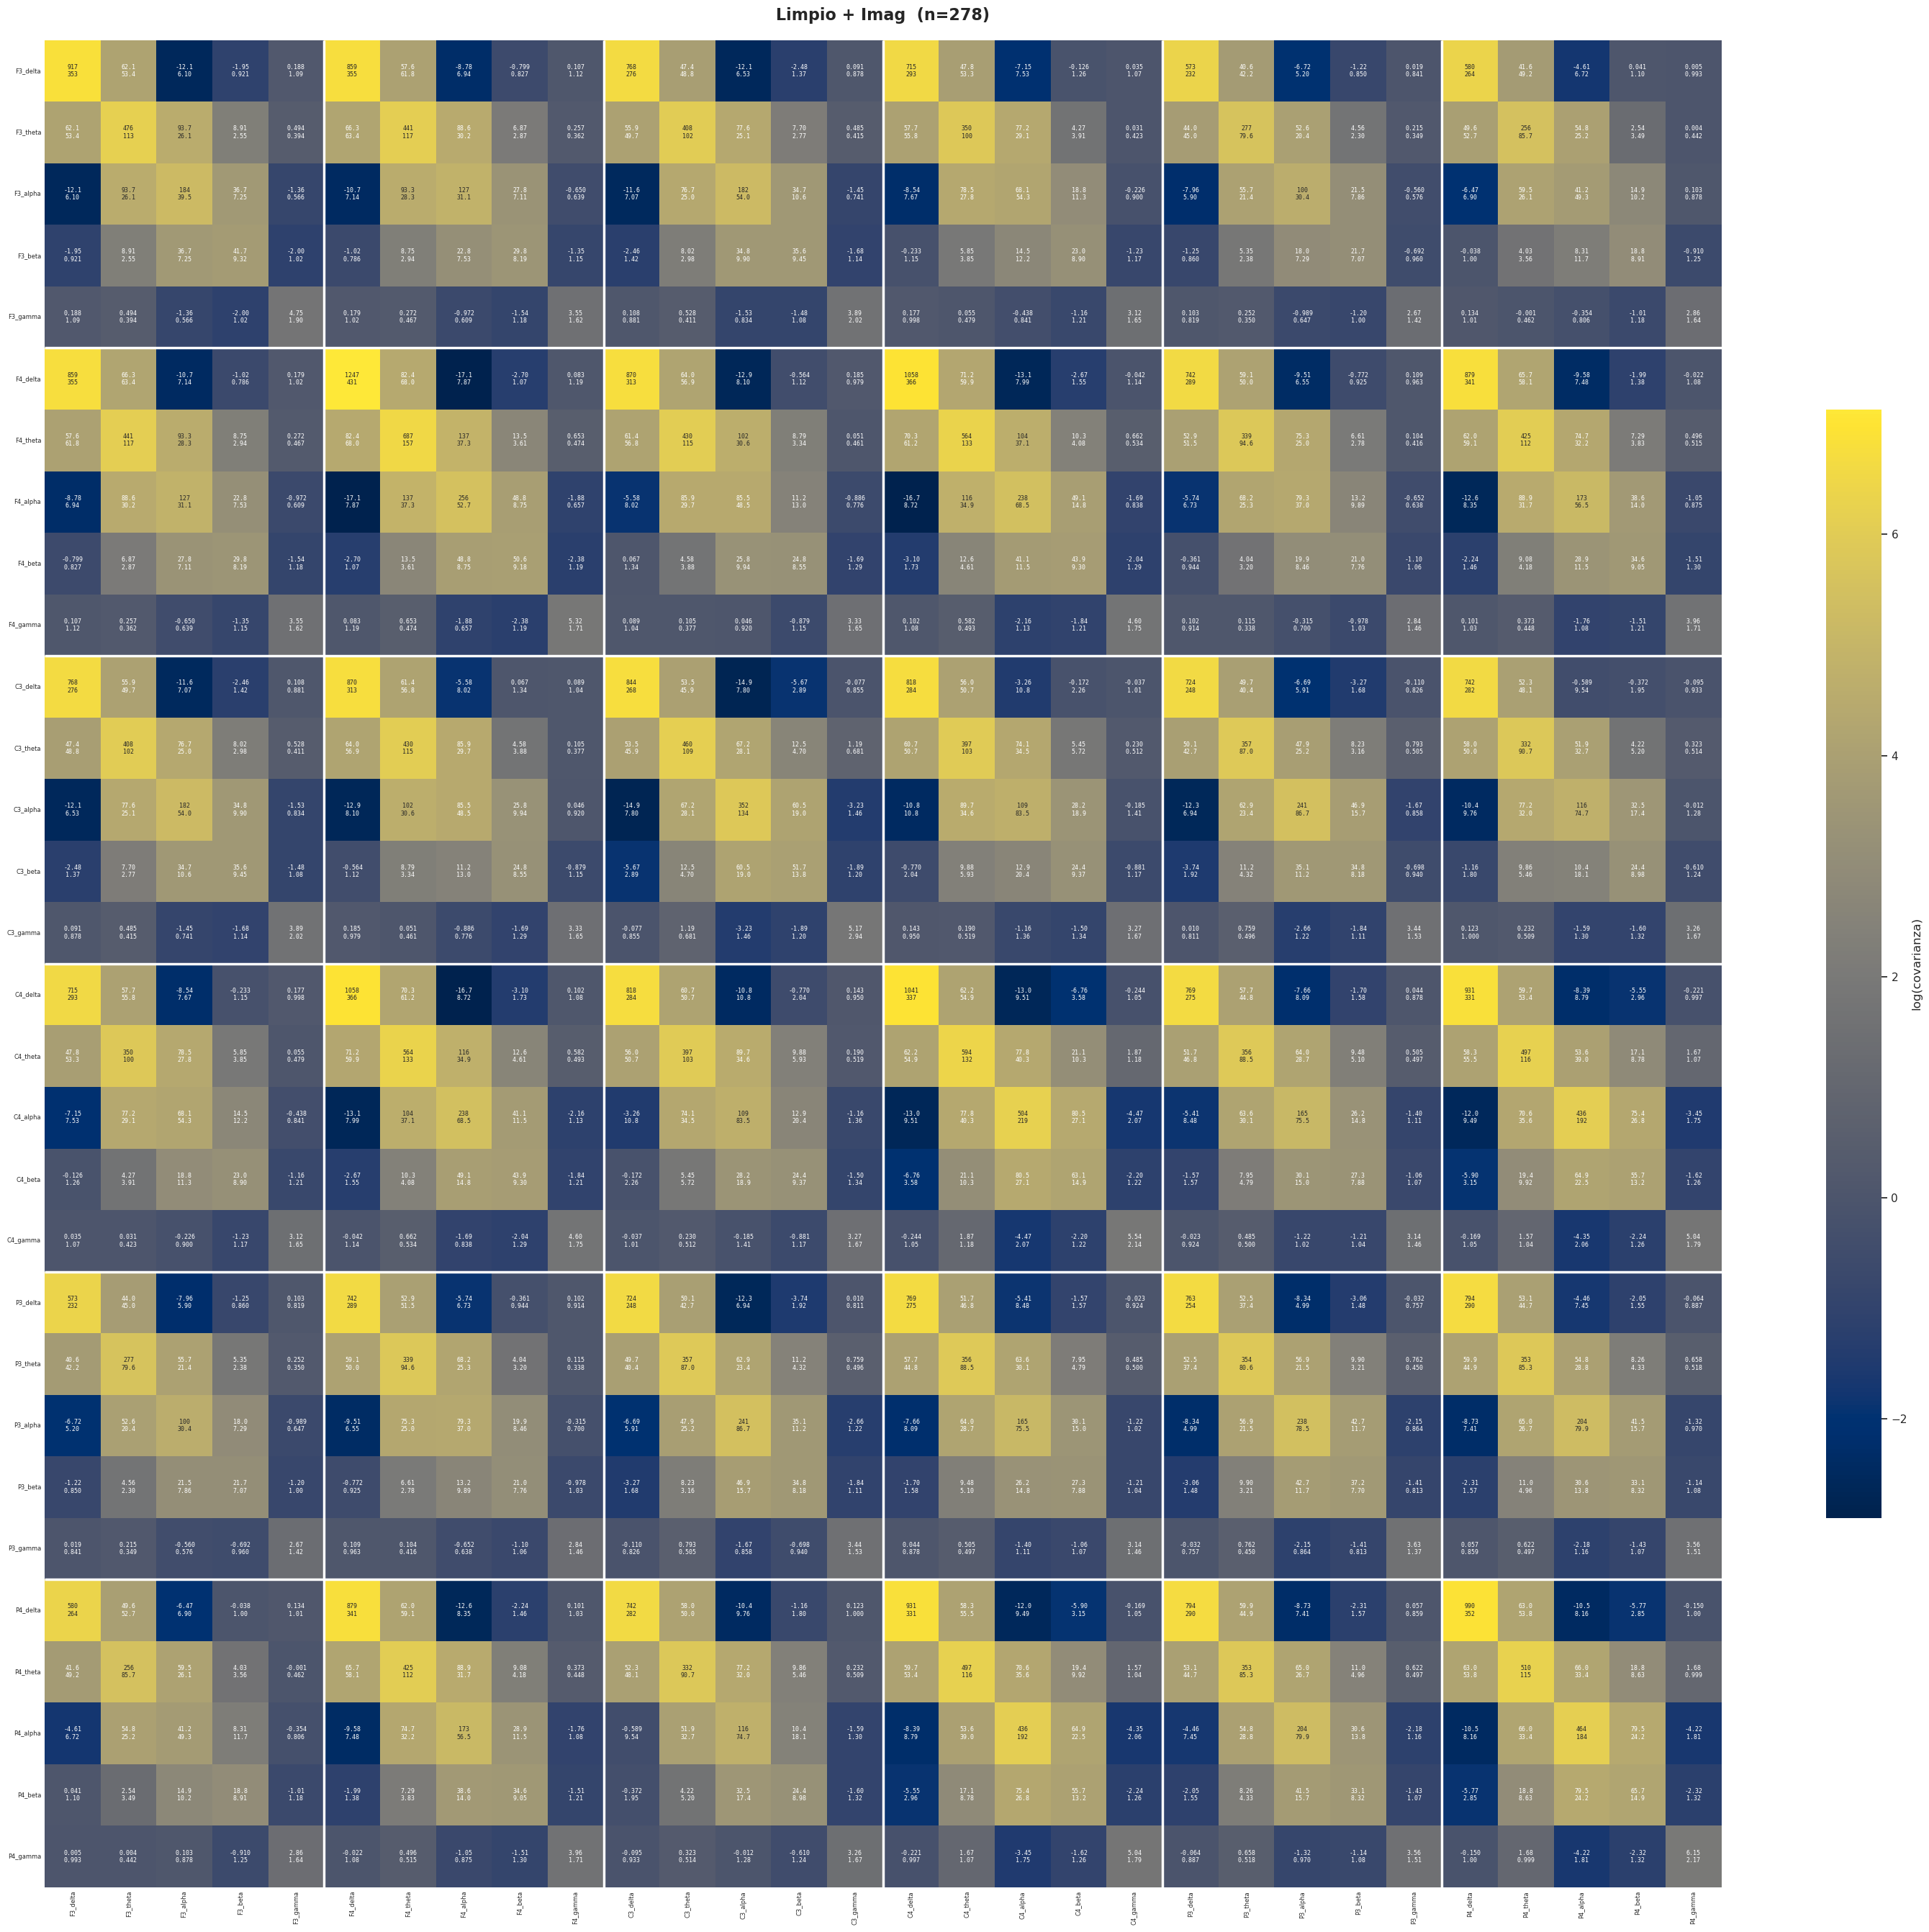

In [51]:
for name, mean_mat, std_mat, n in results:
    plot_cov_matrix(mean_mat, std_mat, name, n)

## 7. Matrices diferencia

Usando `Limpio + Imag` (sin parpadeo ni pronunciación) como línea de base.

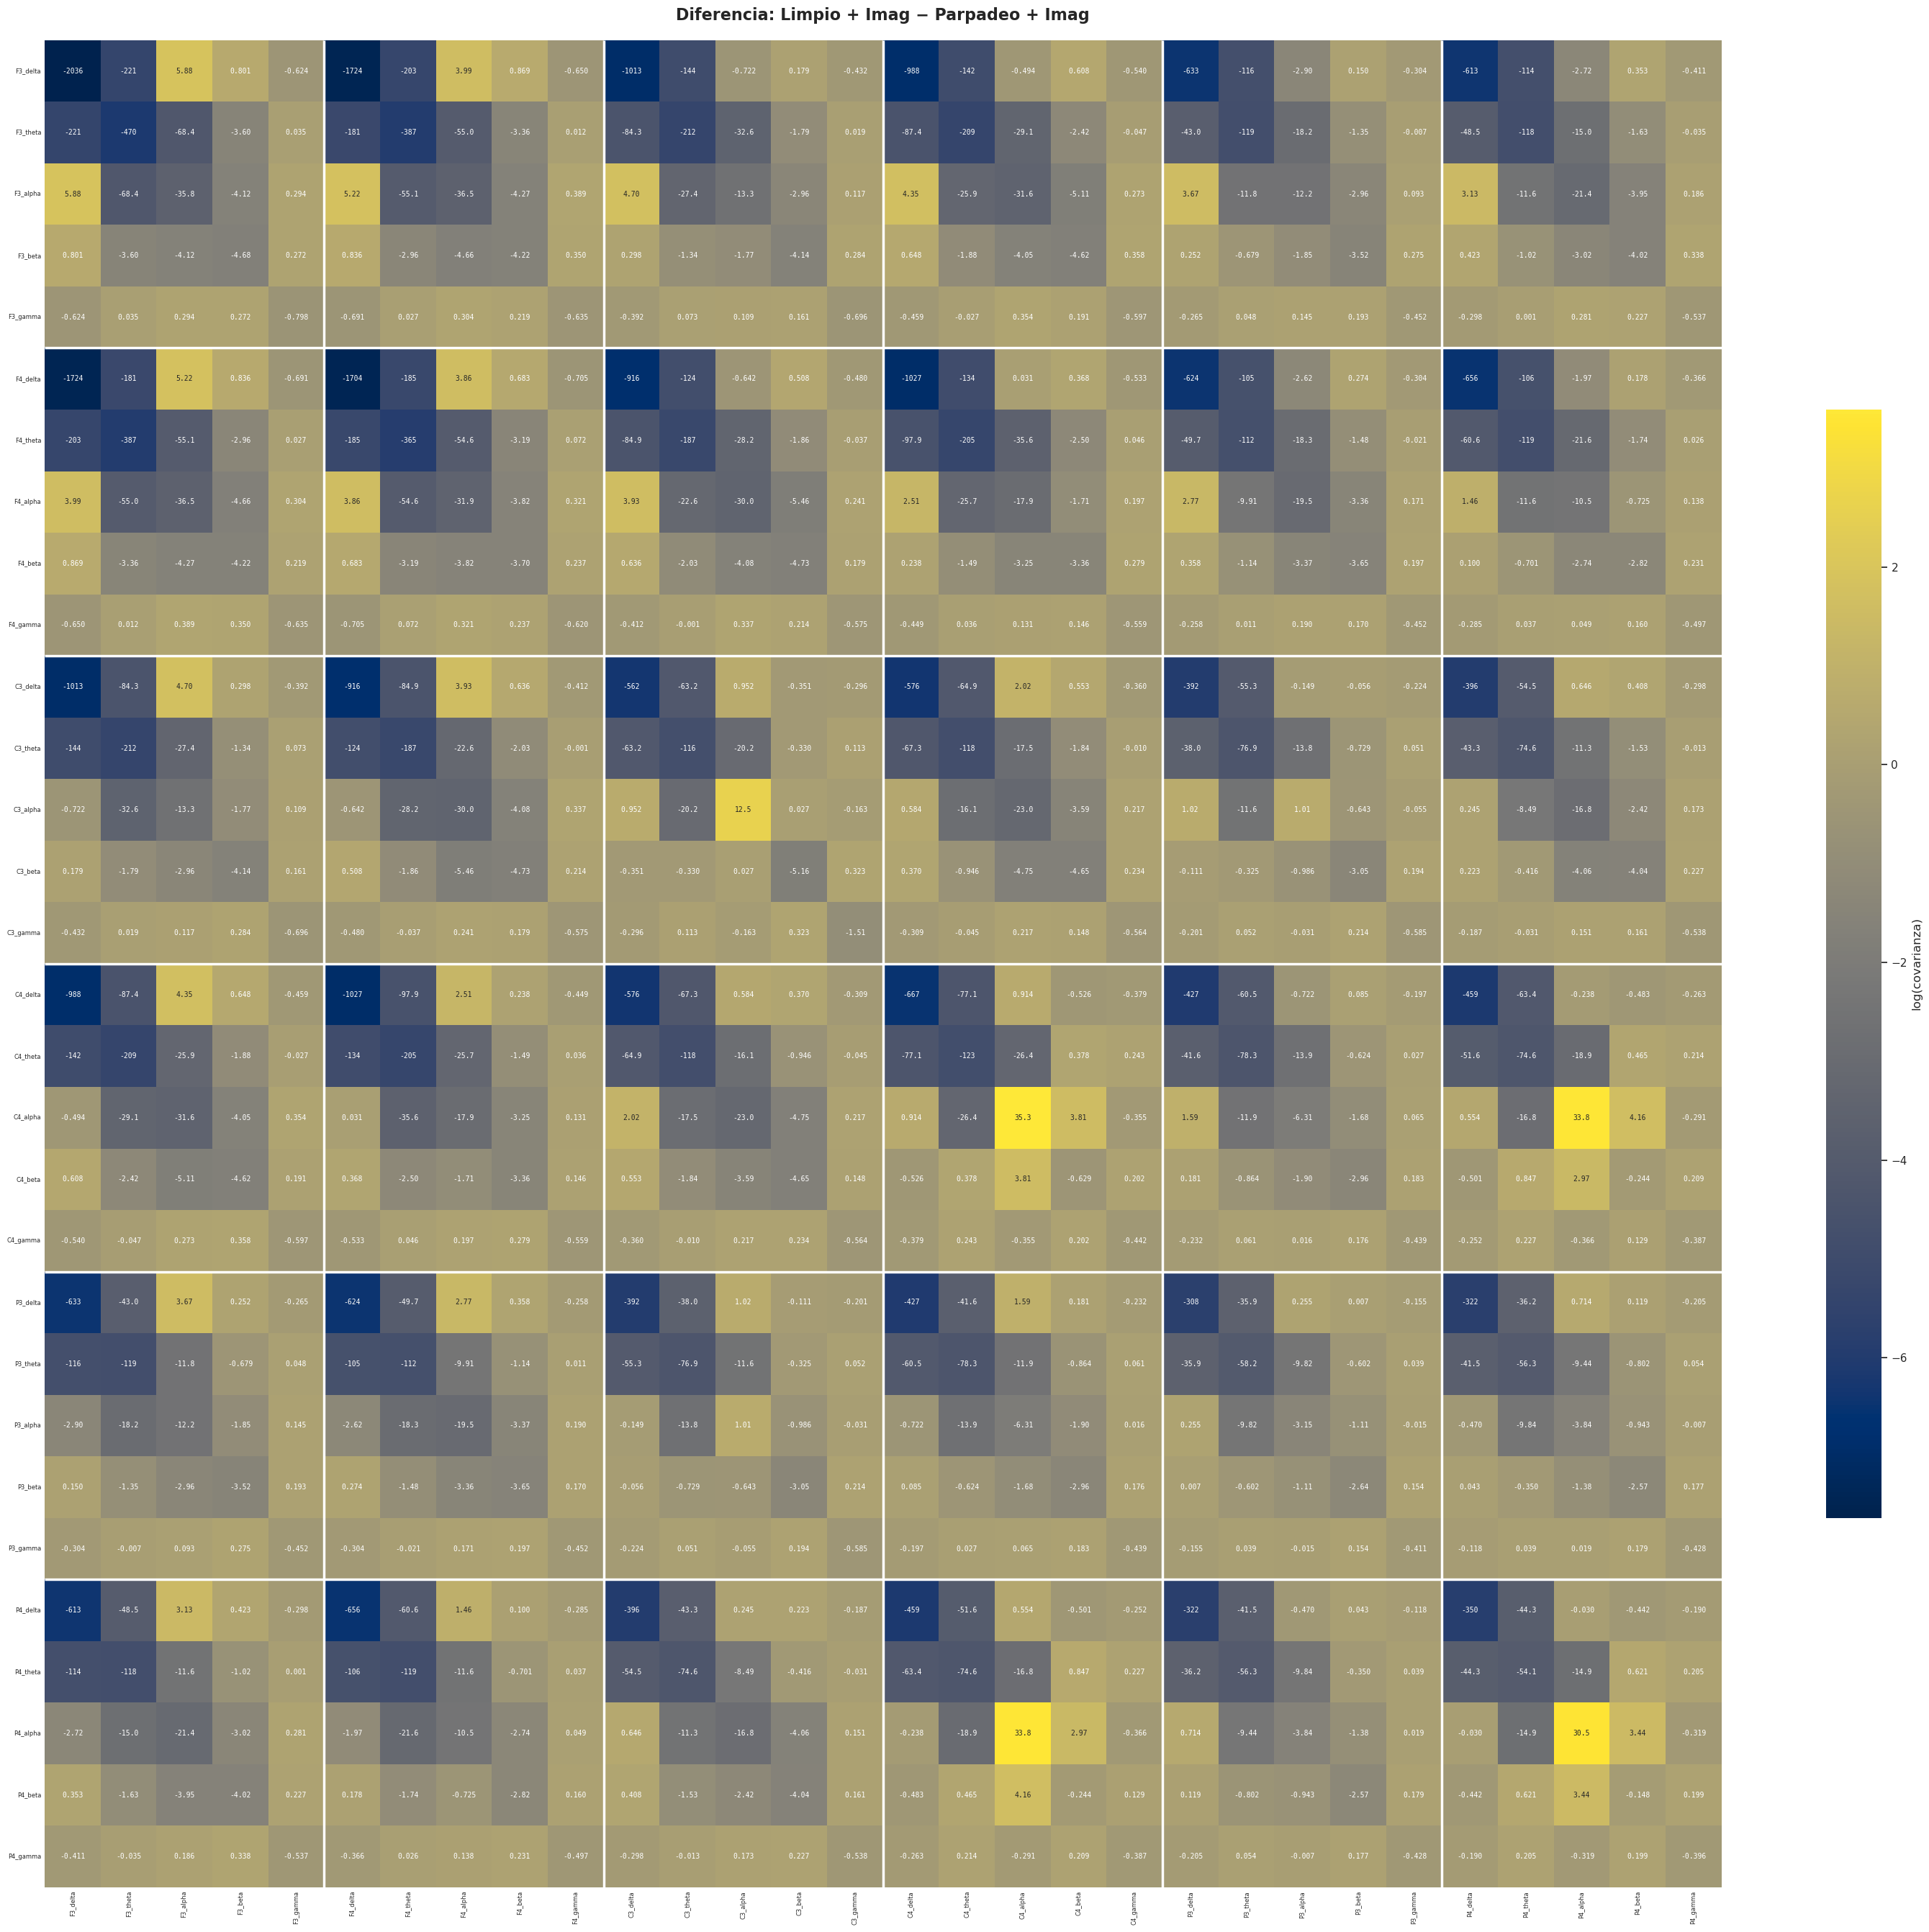

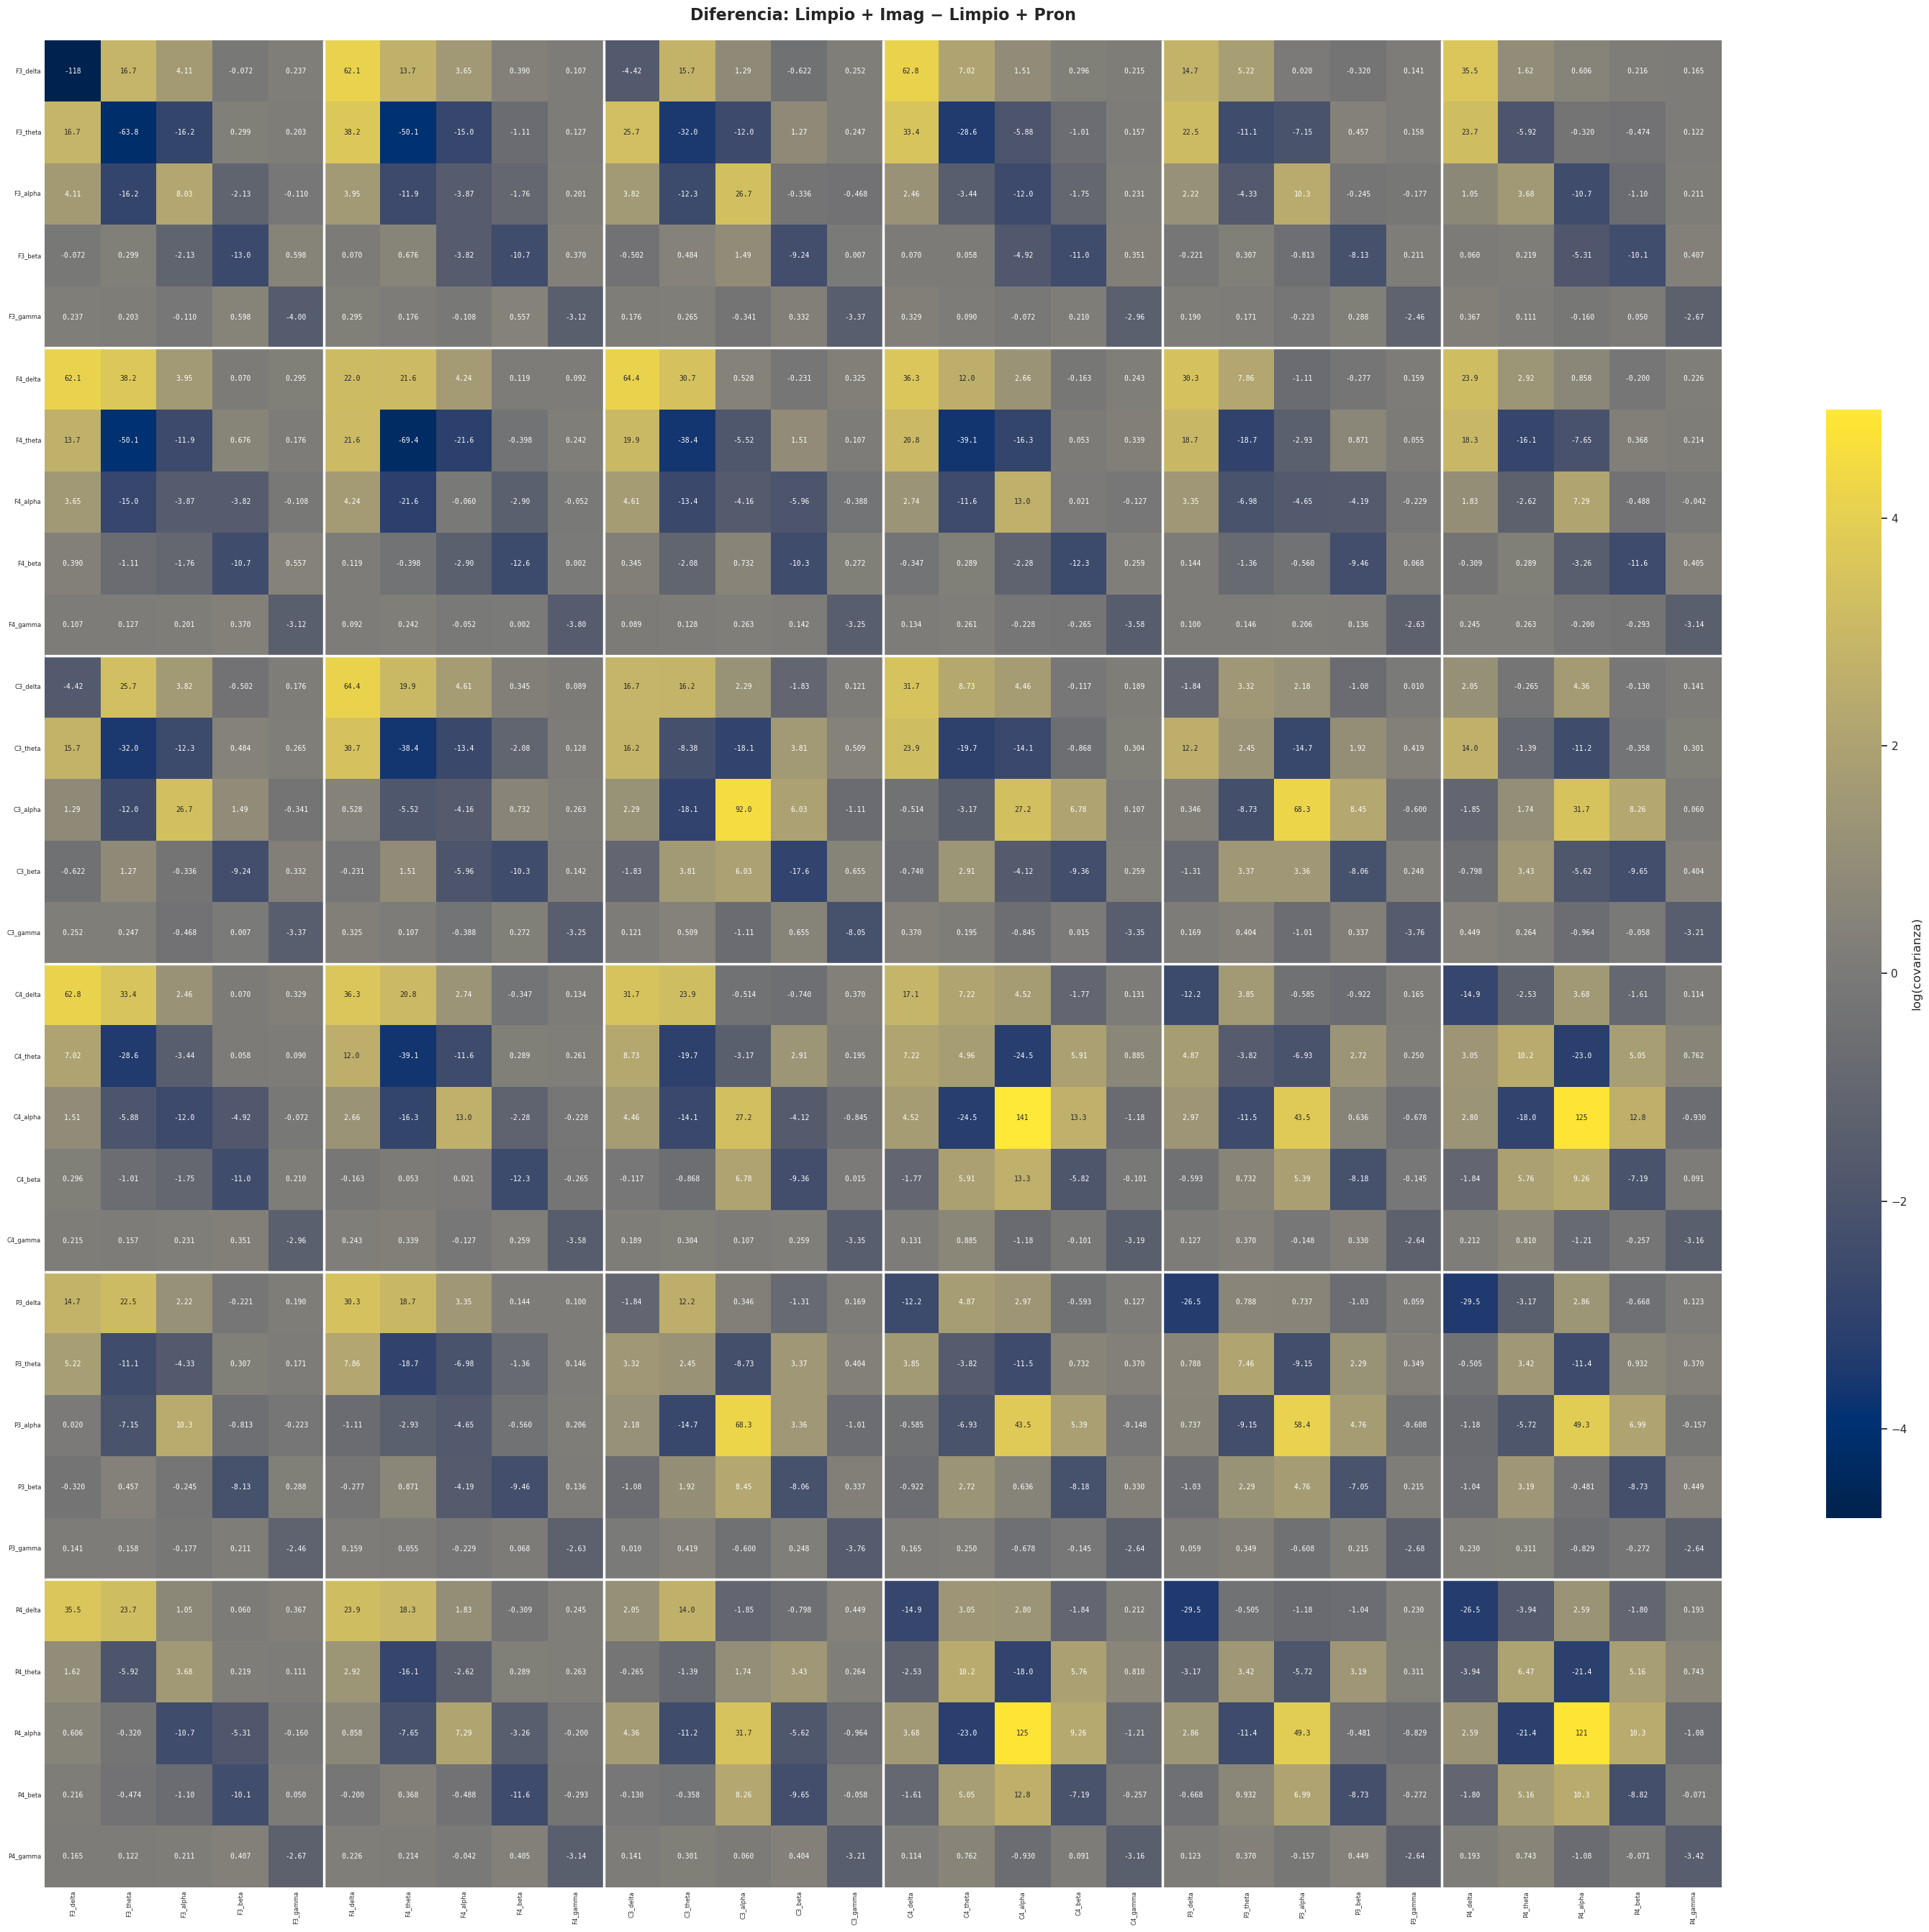

In [52]:
# Índices de los grupos en results
# 0=Todos, 1=Parpadeo, 2=No parpadeo, 3=Pron, 4=Imag, 5=Parp+Pron, 6=Parp+Imag, 7=Limp+Pron, 8=Limp+Imag

base = results[8][1]  # Limpio + Imag (sin parpadeo ni pronunciación)
base_name = results[8][0]

diffs = [
    (f"{base_name} − {results[6][0]}", base - results[6][1]),  # base - Parpadeo+Imag
    (f"{base_name} − {results[7][0]}", base - results[7][1]),  # base - Limpio+Pron
]

for diff_name, diff_mat in diffs:
    annot = np.array([[fmt_val(diff_mat[i,j]) for j in range(N_FEAT)] for i in range(N_FEAT)])
    log_mat = signed_log(diff_mat)
    vmin, vmax = log_mat.min(), log_mat.max()

    fig, ax = plt.subplots(figsize=(30, 27))
    sns.heatmap(log_mat, ax=ax, cmap='cividis',
                vmin=vmin, vmax=vmax,
                annot=annot, fmt='',
                annot_kws={'size': 7, 'fontfamily': 'monospace'},
                xticklabels=FEAT_LABELS, yticklabels=FEAT_LABELS,
                cbar_kws={'label': 'log(covarianza)', 'shrink': 0.6})

    ax.set_xticklabels(FEAT_LABELS, rotation=90, fontsize=6)
    ax.set_yticklabels(FEAT_LABELS, rotation=0, fontsize=6)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)

    for p in range(N_BANDS, N_FEAT, N_BANDS):
        ax.hlines(p, *ax.get_xlim(), color='white', linewidth=2.5, zorder=5)
        ax.vlines(p, *ax.get_ylim(), color='white', linewidth=2.5, zorder=5)

    ax.set_title(f"Diferencia: {diff_name}", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()